## Overall EDA

In [1]:
import gc
import psutil

def check_ram():
    used  = psutil.virtual_memory().used  / 1e9
    total = psutil.virtual_memory().total / 1e9
    pct   = psutil.virtual_memory().percent
    print(f"RAM: {used:.1f}/{total:.1f} GB ({pct:.0f}% used)")

check_ram()

RAM: 1.7/13.6 GB (14% used)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [3]:

from scipy import stats
from scipy.stats import skew
import warnings
warnings.filterwarnings('ignore')



'''
to remove
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_colwidth', 60)
'''

"\nto remove\npd.set_option('display.max_columns', 60)\npd.set_option('display.max_colwidth', 60)\n"

In [4]:
np.random.seed(42)

In [5]:
'''
from google.colab import drive
drive.mount('/content/drive')

import zipfile

zip_path = "/content/drive/MyDrive/Patterns_Milestone_2/Movie_Popularity_Prediction.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")
    '''

'\nfrom google.colab import drive\ndrive.mount(\'/content/drive\')\n\nimport zipfile\n\nzip_path = "/content/drive/MyDrive/Patterns_Milestone_2/Movie_Popularity_Prediction.zip"\n\nwith zipfile.ZipFile(zip_path, \'r\') as zip_ref:\n    zip_ref.extractall("/content/dataset")\n    '

In [6]:
'''
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)
    for f in files:
        print("  ", f)
        '''

'\nimport os\n\nfor root, dirs, files in os.walk("/content/dataset"):\n    print(root)\n    for f in files:\n        print("  ", f)\n        '

In [7]:
import pandas as pd
#df = pd.read_csv("/content/dataset/Movie Popularity Predcition/train_data.csv")

In [8]:
df=pd.read_csv('train_data.csv')
dataframe = df.copy()
dataframe2 = df.copy()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 39 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   id                            1048575 non-null  int64  
 1   title                         1048568 non-null  object 
 2   quality                       1048575 non-null  object 
 3   theatrical                    1048575 non-null  bool   
 4   movie_valence                 253156 non-null   float64
 5   movie_vad_valence             256854 non-null   float64
 6   movie_vad_arousal             256854 non-null   float64
 7   movie_vad_dominance           256854 non-null   float64
 8   movie_intensity_anger         180388 non-null   float64
 9   movie_intensity_anticipation  180388 non-null   float64
 10  movie_intensity_disgust       180388 non-null   float64
 11  movie_intensity_fear          180388 non-null   float64
 12  movie_intensity_joy         

In [10]:
df.head()

,id,title,quality,theatrical,movie_valence,movie_vad_valence,movie_vad_arousal,movie_vad_dominance,movie_intensity_anger,movie_intensity_anticipation,...,original_language,original_title,overview,popularityLevel,poster_path,tagline,genres,production_companies,production_countries,spoken_languages
0,565770,Blue Beetle,real_confident,True,0.434939,0.445939,0.070364,0.405667,0.058714,0.077000,...,en,Blue Beetle,Recent college grad Jaime Reyes returns home f...,High,/mXLOHHc1Zeuwsl4xYKjKh2280oL.jpg,Jaime Reyes is a superhero whether he likes it...,"Action, Science Fiction, Adventure","Warner Bros. Pictures, The Safran Company, DC ...",United States of America,"English, Portuguese, Spanish"
1,980489,Gran Turismo,real_confident,True,0.508375,0.494900,0.231700,0.279400,0.000000,0.000000,...,en,Gran Turismo,The ultimate wish-fulfillment tale of a teenag...,High,/51tqzRtKMMZEYUpSYkrUE7v9ehm.jpg,From gamer to racer.,"Action, Drama, Adventure","PlayStation Productions, 2.0 Entertainment, Co...",United States of America,"English, German, Japanese"
2,968051,The Nun II,real_confident,True,-0.132556,-0.153909,0.115182,0.198364,0.319818,0.097273,...,en,The Nun II,"In 1956 France, a priest is violently murdered...",High,/c9kVD7W8CT5xe4O3hQ7bFWwk68U.jpg,Confess your sins.,"Horror, Mystery, Thriller","New Line Cinema, Atomic Monster, The Safran Co...",United States of America,"English, French"
3,615656,Meg 2: The Trench,real_confident,True,-0.003150,0.100458,0.067333,0.172458,0.000000,0.146500,...,en,Meg 2: The Trench,An exploratory dive into the deepest depths of...,High,/4m1Au3YkjqsxF8iwQy0fPYSxE0h.jpg,Back for seconds.,"Action, Science Fiction, Horror","Apelles Entertainment, Warner Bros. Pictures, ...","China, United States of America",English
4,762430,Retribution,real_confident,True,-0.300000,-0.318333,0.316333,0.096667,0.713667,0.000000,...,en,Retribution,When a mysterious caller puts a bomb under his...,High,/oUmmY7QWWn7OhKlcPOnirHJpP1F.jpg,All roads lead to the truth.,"Action, Mystery, Thriller, Crime","StudioCanal, The Picture Company, Ombra Films","France, United States of America","English, German"


In [11]:
null_columns=[col for col in df.columns if df[col].isnull().any()]

#### Null drops

In [12]:
df.isnull().sum().sort_values()

,0
id,0
quality,0
theatrical,0
runtime,0
status,0
revenue,0
vote_average,0
vote_count,0
budget,0
original_language,0


In [13]:
no_null_cols = [
    'id', 'quality', 'theatrical', 'runtime', 'status',
    'revenue', 'vote_average', 'vote_count',
    'budget', 'original_language', 'popularityLevel'
]
df_nulls = df.drop(columns=no_null_cols)

In [14]:
row_null_pct = df_nulls.isnull().mean(axis=1)

In [15]:
bins = pd.cut(
    row_null_pct,
    bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    include_lowest=True
)

distribution = bins.value_counts().sort_index()
distribution

,count
"(-0.001, 0.1]",75590
"(0.1, 0.2]",75358
"(0.2, 0.3]",26352
"(0.3, 0.4]",31358
"(0.4, 0.5]",39019
"(0.5, 0.6]",75551
"(0.6, 0.7]",282164
"(0.7, 0.8]",317608
"(0.8, 0.9]",125503
"(0.9, 1.0]",72


In [16]:
df['row_null_pct'] = row_null_pct

In [17]:
df['popularityLevel'].value_counts(normalize=True) * 100

,proportion
popularityLevel,
Very Low,77.073171
Low,14.015497
Medium,7.433422
High,1.477910


In [18]:
df.groupby('popularityLevel')['row_null_pct'].mean()
# calculating % nulls per class

,row_null_pct
popularityLevel,
High,0.118703
Low,0.490553
Medium,0.309525
Very Low,0.642946


####Findings suggest missingness is NOT at random. The more popular a movie is, the less missing data it has.

In [19]:
# Before dropping
rows_to_drop = df[df['row_null_pct'] > 0.95]
print(rows_to_drop['popularityLevel'].value_counts(normalize=True) * 100)

popularityLevel
Very Low    100.0
Name: proportion, dtype: float64


In [20]:
df = df[df['row_null_pct'] <= 0.95].copy()

In [21]:
len(df)

1048573

####Check Class imbalance

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [23]:
order = ['Very Low', 'Low', 'Medium', 'High']

In [24]:
counts = df['popularityLevel'].value_counts()
percentages   = df['popularityLevel'].value_counts(normalize=True) * 100

In [25]:
imbalance_df= pd.DataFrame({
    'Count': counts,
    'Percentage': percentages
}).reindex(order)

In [26]:
ratio = counts.max() / counts.min()
print(f"Imbalance Ratio: {ratio:.2f}x")


Imbalance Ratio: 52.15x


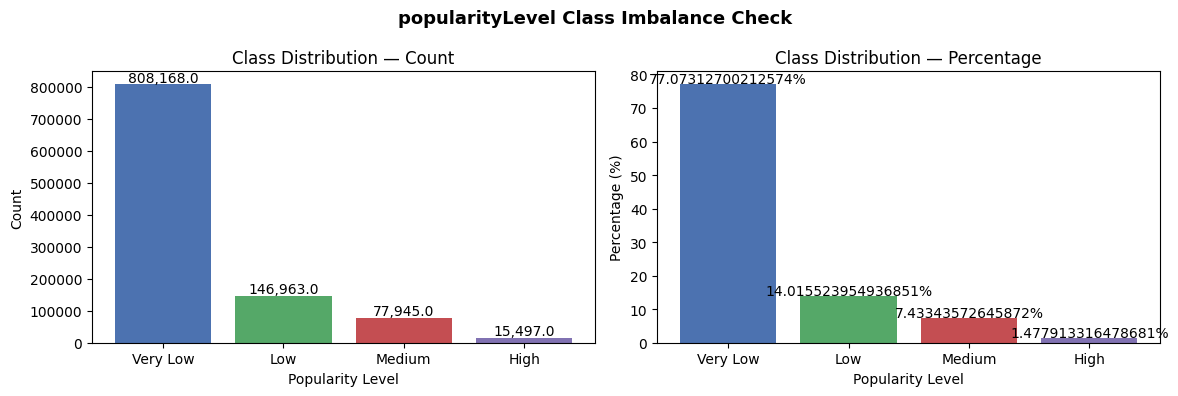

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#count plot
axes[0].bar(imbalance_df.index, imbalance_df['Count'],
            color=['#4C72B0','#55A868','#C44E52','#8172B2'])
axes[0].set_title('Class Distribution — Count')
axes[0].set_xlabel('Popularity Level')
axes[0].set_ylabel('Count')
for i, (idx, row) in enumerate(imbalance_df.iterrows()):
    axes[0].text(i, row['Count'] + imbalance_df['Count'].max()*0.01,
                 f"{row['Count']:,}", ha='center', fontsize=10)

# Percentage plot
axes[1].bar(imbalance_df.index, imbalance_df['Percentage'],
            color=['#4C72B0','#55A868','#C44E52','#8172B2'])
axes[1].set_title('Class Distribution — Percentage')
axes[1].set_xlabel('Popularity Level')
axes[1].set_ylabel('Percentage (%)')
for i, (idx, row) in enumerate(imbalance_df.iterrows()):
    axes[1].text(i, row['Percentage'] + 0.3,
                 f"{row['Percentage']}%", ha='center', fontsize=10)

plt.suptitle('popularityLevel Class Imbalance Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

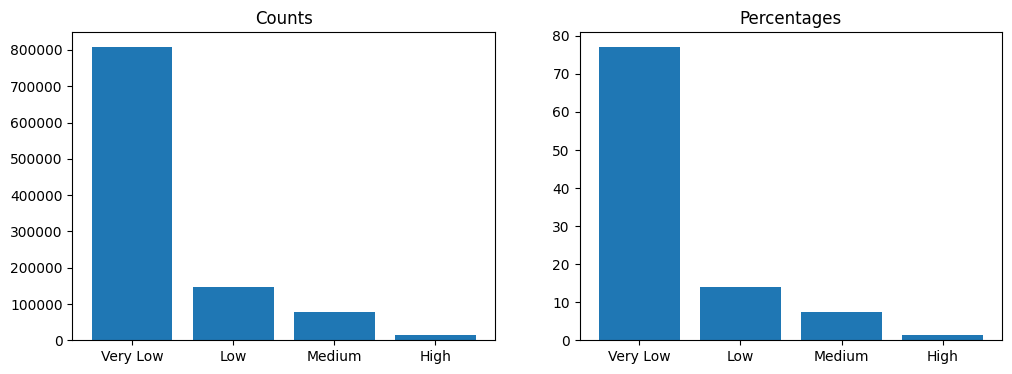

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# count plot
ax[0].bar(order, counts)
ax[0].set_title("Counts")
# Percentage plot
ax[1].bar(order, percentages)
ax[1].set_title("Percentages")
plt.show()

#####drop high null rows protecting rare classes

In [29]:
row_null_pct_with_noNullscols = df.isnull().mean(axis=1)

rare_classes  = ['High', 'Medium', 'Low']


is_high_null  = row_null_pct_with_noNullscols > 0.9
is_not_rare   = ~df['popularityLevel'].isin(rare_classes)


In [30]:
rows_to_drop = is_high_null & is_not_rare


In [31]:
print("Rows dropped:", rows_to_drop.sum())
print("Rows kept:", (~rows_to_drop).sum())




Rows dropped: 0
Rows kept: 1048573


In [32]:
print("Dropped rows classes:")
print(df[rows_to_drop]['popularityLevel'].value_counts())

Dropped rows classes:
Series([], Name: count, dtype: int64)


In [33]:
df_clean = df[~rows_to_drop].reset_index(drop=True)

In [34]:
print("New shape:", df_clean.shape)

New shape: (1048573, 40)


In [35]:
print("New class counts:")
print(df_clean['popularityLevel'].value_counts())

New class counts:
popularityLevel
Very Low    808168
Low         146963
Medium       77945
High         15497
Name: count, dtype: int64


In [36]:
print("New class percentages:")
print((df_clean['popularityLevel'].value_counts(normalize=True) * 100).round(2))

New class percentages:
popularityLevel
Very Low    77.07
Low         14.02
Medium       7.43
High         1.48
Name: proportion, dtype: float64


In [37]:
# it was found that cleaning the data too aggresively negatively affected some models (such as Logistic Regression).

In [38]:
df = df_clean.copy()

## Column wise preprocesing

###popularity level


In [39]:
from sklearn.preprocessing import LabelEncoder


In [40]:
label_map = {'Very Low': 0, 'Low': 1, 'Medium': 2, 'High': 3}

df['target'] = df['popularityLevel'].map(label_map)

In [41]:
print("\nLabel encoding applied:")

print(df[['popularityLevel', 'target']].drop_duplicates().sort_values('target'))


Label encoding applied:
       popularityLevel  target
240405        Very Low       0
93442              Low       1
15497           Medium       2
0                 High       3


In [42]:
len(df)

1048573

In [43]:

df['target'] = df['popularityLevel'].map(label_map)

In [44]:


df = df.drop(columns=['popularityLevel'])


### Overall EDA

In [45]:
null_ratio = (df.isnull().sum() / len(df)).sort_values(ascending=False)
null_ratio_df = null_ratio.reset_index()
null_ratio_df.columns = ['column', 'null_ratio']
print(null_ratio_df)

                          column  null_ratio
0                       homepage    0.883241
1                        tagline    0.857647
2                movie_scl_shift    0.828447
3   movie_intensity_anticipation    0.827968
4          movie_intensity_anger    0.827968
5        movie_intensity_disgust    0.827968
6        movie_intensity_sadness    0.827968
7            movie_intensity_joy    0.827968
8          movie_intensity_trust    0.827968
9           movie_intensity_fear    0.827968
10      movie_intensity_surprise    0.827968
11                 movie_valence    0.758571
12             movie_vad_arousal    0.755044
13             movie_vad_valence    0.755044
14           movie_vad_dominance    0.755044
15            movie_scl_coverage    0.741863
16                 backdrop_path    0.729429
17          production_companies    0.566279
18                       imdb_id    0.445386
19          production_countries    0.423912
20              spoken_languages    0.401092
21        

In [46]:
pip install missingno

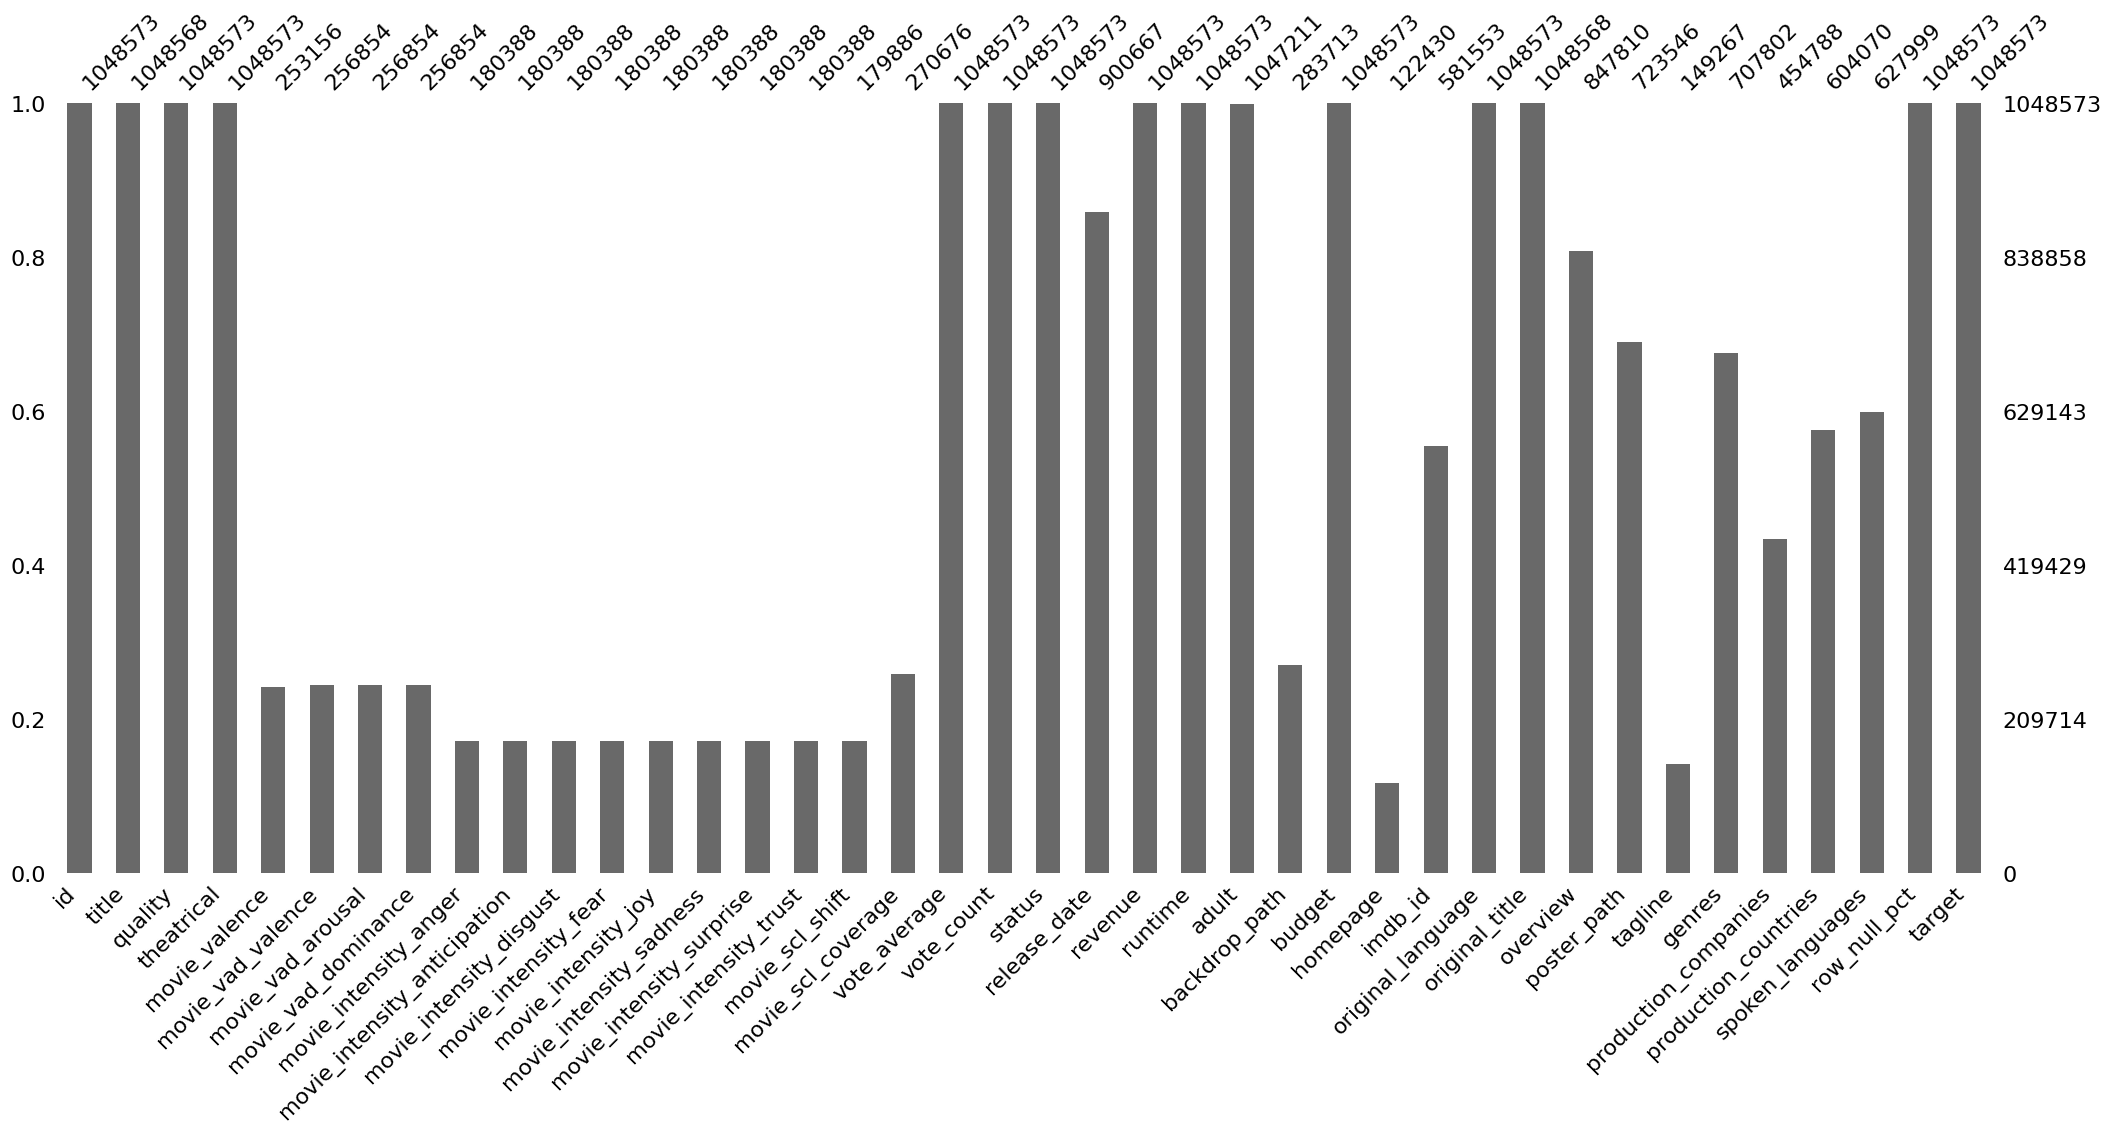

In [47]:
import missingno
missingno.bar(df)
plt.show()

In [48]:
'''
df['log_popularity'] = np.log1p(df['popularity'])
num_df = df.select_dtypes(include=[np.number])

corr = num_df.corr()
plt.title("Correlation Heatmap")
sns.heatmap(corr, cmap='coolwarm')
plt.show()
'''

'\ndf[\'log_popularity\'] = np.log1p(df[\'popularity\'])\nnum_df = df.select_dtypes(include=[np.number])\n\ncorr = num_df.corr()\nplt.title("Correlation Heatmap")\nsns.heatmap(corr, cmap=\'coolwarm\')\nplt.show()\n'

In [49]:
''''
corr_target = corr['log_popularity'].sort_values(ascending=False)
print(corr_target)
'''

"'\ncorr_target = corr['log_popularity'].sort_values(ascending=False)\nprint(corr_target)\n"

In [50]:
#correlation is v low for the intensity columns + valence/vad columns , and they have 80% nulls , will drop

In [51]:
emotion_cols = ['movie_intensity_anger', 'movie_intensity_disgust','movie_intensity_joy', 'movie_intensity_sadness','movie_intensity_trust', 'movie_intensity_fear','movie_intensity_surprise', 'movie_intensity_anticipation','movie_vad_valence', 'movie_vad_arousal', 'movie_vad_dominance','movie_valence', 'movie_scl_shift', 'movie_scl_coverage']

df.drop(columns=emotion_cols, inplace=True)

In [52]:
df.duplicated().sum()

np.int64(166)

In [53]:
df.drop(columns=['id'],inplace=True)

In [54]:
df.drop_duplicates(inplace=True)

In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
df.head()

,title,quality,theatrical,vote_average,vote_count,status,release_date,revenue,runtime,adult,...,original_title,overview,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,row_null_pct,target
0,Blue Beetle,real_confident,True,7.139,1023,Released,8/16/2023,124818235,128,False,...,Blue Beetle,Recent college grad Jaime Reyes returns home f...,/mXLOHHc1Zeuwsl4xYKjKh2280oL.jpg,Jaime Reyes is a superhero whether he likes it...,"Action, Science Fiction, Adventure","Warner Bros. Pictures, The Safran Company, DC ...",United States of America,"English, Portuguese, Spanish",0.0,3
1,Gran Turismo,real_confident,True,8.068,702,Released,8/9/2023,114800000,135,False,...,Gran Turismo,The ultimate wish-fulfillment tale of a teenag...,/51tqzRtKMMZEYUpSYkrUE7v9ehm.jpg,From gamer to racer.,"Action, Drama, Adventure","PlayStation Productions, 2.0 Entertainment, Co...",United States of America,"English, German, Japanese",0.0,3
2,The Nun II,real_confident,True,6.545,365,Released,9/6/2023,231200000,110,False,...,The Nun II,"In 1956 France, a priest is violently murdered...",/c9kVD7W8CT5xe4O3hQ7bFWwk68U.jpg,Confess your sins.,"Horror, Mystery, Thriller","New Line Cinema, Atomic Monster, The Safran Co...",United States of America,"English, French",0.0,3
3,Meg 2: The Trench,real_confident,True,6.912,2034,Released,8/2/2023,384056482,116,False,...,Meg 2: The Trench,An exploratory dive into the deepest depths of...,/4m1Au3YkjqsxF8iwQy0fPYSxE0h.jpg,Back for seconds.,"Action, Science Fiction, Horror","Apelles Entertainment, Warner Bros. Pictures, ...","China, United States of America",English,0.0,3
4,Retribution,real_confident,True,6.816,258,Released,8/23/2023,12905464,91,False,...,Retribution,When a mysterious caller puts a bomb under his...,/oUmmY7QWWn7OhKlcPOnirHJpP1F.jpg,All roads lead to the truth.,"Action, Mystery, Thriller, Crime","StudioCanal, The Picture Company, Ombra Films","France, United States of America","English, German",0.0,3


### Text Handling  

In [57]:
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

In [58]:
text_cols = {
    'overview': df.get('overview', pd.Series('')),
    'tagline' : df.get('tagline',  pd.Series('')),
}


In [59]:
df['text_combined'] = (
    df.get('overview', pd.Series('')).fillna('') + ' ' +
    df.get('tagline',  pd.Series('')).fillna('') + ' '
).str.strip()

In [60]:
df['text_combined'] = df['text_combined'].replace('', 'no description')


### Title

In [61]:
df.columns

Index(['title', 'quality', 'theatrical', 'vote_average', 'vote_count',
       'status', 'release_date', 'revenue', 'runtime', 'adult',
       'backdrop_path', 'budget', 'homepage', 'imdb_id', 'original_language',
       'original_title', 'overview', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'row_null_pct', 'target', 'text_combined'],
      dtype='object')

In [62]:
df.loc[df['title']!=df['original_title'],['title','original_title']]

,title,original_title
10,Operation Napoleon,Napóleonsskjölin
15,Let Her Kill You,Seule : Les dossiers Silvercloud
35,My Fault,Culpa mía
39,Adipurush,आदिपुरुष
42,Deep Sea Python,深海巨蟒
...,...,...
1048546,Magic 8-Ball,Bola 8
1048554,Things We Get Used To,익숙해지는 것들에 대하여
1048557,I Do Not Love My Future; I Love Guan Yin,我不爱前程爱观音
1048563,Riaru Kimo-dameshi,リアル肝試し


In [63]:
df[['title','original_title']].isnull().sum()

,0
title,5
original_title,5


Drop bec most of the column is **unique** not useful for learning


In [64]:
df['title'].nunique()

893644

In [65]:
df.drop(columns=['title', 'original_title'], inplace=True)

### Theatrical

In [66]:
df['theatrical'].isnull().sum()

np.int64(0)

In [67]:
df['theatrical'].value_counts(normalize=True)

,proportion
theatrical,
True,0.950645
False,0.049355


In [68]:
df['theatrical'] = df['theatrical'].astype(int)

In [69]:
df['theatrical'].value_counts(normalize=True)

,proportion
theatrical,
1,0.950645
0,0.049355


### Vote_avg & vote_count

In [70]:
df['vote_average'].describe()

,vote_average
count,1.048323e+06
mean,1.899281e+00
std,3.010345e+00
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,4.833000e+00
max,1.000000e+01


In [71]:
skew(df['vote_average'])

np.float64(1.1821185674606753)

In [72]:
# not skewed

In [73]:
df['vote_average'].isnull().sum()

np.int64(0)

In [74]:
df['vote_count'].describe()

,vote_count
count,1.048323e+06
mean,2.039109e+01
std,3.312403e+02
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,1.000000e+00
max,3.449500e+04


In [75]:
skew(df['vote_count'])

np.float64(39.38906861585813)

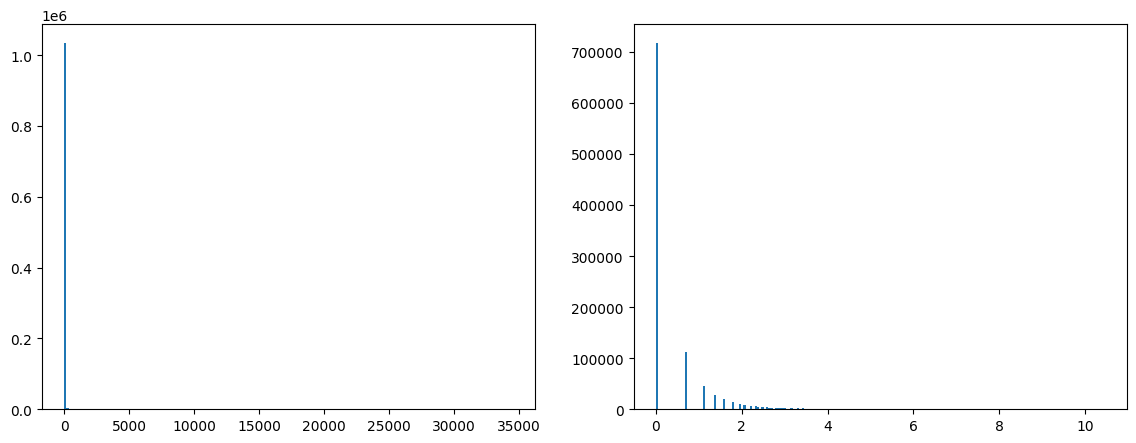

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['vote_count'], bins=200)
axes[1].hist(np.log1p(df['vote_count']), bins=200)

plt.show()

In [77]:
df['vote_count_log'] = np.log1p(df['vote_count'])

In [78]:
df['vote_count_log'].isnull().sum()

np.int64(0)

In [79]:
df.drop(columns=['vote_count'],inplace=True)

### Adult

In [80]:
df['adult'].isnull().sum()

np.int64(1361)

In [81]:
df['adult'].value_counts()

,count
adult,
False,1046181
True,781


In [82]:
## no variation almost 99.9% is False, will ad no significant info only noise, drop

In [83]:
df.drop(columns=['adult'],inplace=True)

### homepage

In [84]:
df['homepage'].head()

,homepage
0,https://www.dc.com/bluebeetle
1,https://www.granturismo.movie
2,https://www.warnerbros.com/movies/nun2
3,https://www.themeg.movie
4,https://iiil.io/jCT7


In [85]:
df['homepage'].isnull().sum()

np.int64(925920)

In [86]:
df.drop(columns=['homepage'],inplace=True)

Also won't contribute much in learning , mostly unique value

In [87]:
df.drop(columns=['imdb_id'],inplace=True)

### Original Language


In [88]:
from collections import Counter

In [89]:
freq=Counter(df['original_language'].values)

In [90]:
df['original_language'].isnull().sum()

np.int64(0)

In [91]:
freq.most_common(5)

[('en', 531515), ('fr', 67703), ('es', 60815), ('de', 48952), ('ja', 43423)]

In [92]:
df['original_language'].value_counts()

,count
original_language,
en,531515
fr,67703
es,60815
de,48952
ja,43423
...,...
kj,1
kv,1
aa,1


In [93]:
top_langs = df['original_language'].value_counts().nlargest(5).index

df['original_language'] = df['original_language'].apply(lambda x: x if x in top_langs else 'other')
df = pd.get_dummies(df, columns=['original_language'], prefix='lang')

### backdrop path

In [94]:
df['backdrop_path'].head()

,backdrop_path
0,/1syW9SNna38rSl9fnXwc9fP7POW.jpg
1,/xFYpUmB01nswPgbzi8EOCT1ZYFu.jpg
2,/53z2fXEKfnNg2uSOPss2unPBGX1.jpg
3,/5mzr6JZbrqnqD8rCEvPhuCE5Fw2.jpg
4,/iiXliCeykkzmJ0Eg9RYJ7F2CWSz.jpg


In [95]:
df.drop(columns=['backdrop_path'],inplace=True)

### Status

In [96]:
df['status'].isnull().sum()

np.int64(0)

In [97]:
df['status'].value_counts()

,count
status,
Released,1010813
In Production,17675
Post Production,10992
Planned,8179
Rumored,414
Canceled,250


In [98]:
#split

In [99]:
df['is_released'] = (df['status'] == 'Released').astype(int)

df['is_in_pipeline'] = df['status'].isin(
    ['In Production','Post Production','Planned']).astype(int)

df['is_uncertain'] = (df['status']=='Rumored').astype(int)

df['is_canceled'] = (df['status'] == 'Canceled').astype(int)

In [100]:
df.drop(columns=['status'],inplace=True)

### Production Companies

In [101]:
df['production_companies'].value_counts()

,count
production_companies,
ONF | NFB,2331
BBC,2109
Metro-Goldwyn-Mayer,2031
Columbia Pictures,1941
Toei Company,1789
...,...
dfm Fiktion,1
"Augenschein Filmproduktion, Capricci Films, Kazakhfilm Studios",1
"A. G. Nadiadwala, A. G. Films",1


In [102]:
df['production_companies_list'] = df['production_companies'].fillna('').apply(
    lambda x: [c.strip() for c in x.split(',')] if x != '' else []
)

In [103]:
from itertools import chain

In [104]:
all_companies = list(chain.from_iterable(df['production_companies_list']))
company_counts = pd.Series(all_companies).value_counts()
print(company_counts.head(30))


Warner Bros. Pictures            3226
BBC                              3099
Columbia Pictures                2931
Metro-Goldwyn-Mayer              2857
ARTE                             2799
ONF | NFB                        2757
Universal Pictures               2688
Paramount                        2601
ZDF                              2329
Toei Company                     2259
Nikkatsu Corporation             1863
20th Century Fox                 1705
ARD                              1534
Mosfilm                          1528
Canal+                           1517
TOHO                             1413
Shochiku                         1369
Česká televize                   1341
France Télévisions               1238
RKO Radio Pictures               1192
CNC                              1110
Walt Disney Productions          1109
SVT                              1096
RAI                              1062
DEFA                             1038
WDR                               973
Českoslovens

In [105]:
top_companies = company_counts.head(25).index.tolist()
print(top_companies)

df['no_of_large_production_companies'] = df['production_companies_list'].apply(
    lambda companies: int(sum(c in top_companies for c in companies))
)


['Warner Bros. Pictures', 'BBC', 'Columbia Pictures', 'Metro-Goldwyn-Mayer', 'ARTE', 'ONF | NFB', 'Universal Pictures', 'Paramount', 'ZDF', 'Toei Company', 'Nikkatsu Corporation', '20th Century Fox', 'ARD', 'Mosfilm', 'Canal+', 'TOHO', 'Shochiku', 'Česká televize', 'France Télévisions', 'RKO Radio Pictures', 'CNC', 'Walt Disney Productions', 'SVT', 'RAI', 'DEFA']


In [106]:
df.isnull().sum()

,0
quality,0
theatrical,0
vote_average,0
release_date,147768
revenue,0
runtime,0
budget,0
overview,200677
poster_path,324882
tagline,899090


In [107]:
df['num_production_companies'] = df['production_companies_list'].apply(len)

In [108]:
df.drop(columns=['production_companies','production_companies_list'], inplace=True)

### poster path +tagline

In [109]:
df['poster_path'].head()

,poster_path
0,/mXLOHHc1Zeuwsl4xYKjKh2280oL.jpg
1,/51tqzRtKMMZEYUpSYkrUE7v9ehm.jpg
2,/c9kVD7W8CT5xe4O3hQ7bFWwk68U.jpg
3,/4m1Au3YkjqsxF8iwQy0fPYSxE0h.jpg
4,/oUmmY7QWWn7OhKlcPOnirHJpP1F.jpg


In [110]:
df.drop(columns=['poster_path'], inplace=True)

In [111]:
df['tagline'].isnull().sum()*100/len(df)

np.float64(85.764597361691)

In [112]:
# 85% is null , and similar to overview which was handled in detail

In [113]:
df.drop(columns='tagline', inplace=True)

### Quality

In [114]:
df['quality'].value_counts(normalize=True)

,proportion
quality,
stub_uncertain,0.396200
real_likely,0.303343
stub_legitimate,0.170126
real_confident,0.103562
spam_confident,0.020946
spam_likely,0.005824


In [115]:
df['quality'].unique()

array(['real_confident', 'stub_legitimate', 'real_likely',
       'stub_uncertain', 'spam_confident', 'spam_likely'], dtype=object)

In [116]:
df['quality'].isnull().sum()

np.int64(0)

In [117]:
df['quality_type'] = df['quality'].str.split('_').str[0]

In [118]:
df['quality_type'].value_counts()

,count
quality_type,
stub,593693
real,426567
spam,28063


In [119]:
df['quality_confidence'] = df['quality'].str.split('_').str[1]

In [120]:
df['quality_confidence'].value_counts()

,count
quality_confidence,
uncertain,415346
likely,324106
legitimate,178347
confident,130524


In [121]:
quality_map={'spam':-1, 'stub':0, 'real':1}
df['quality_type']=df['quality_type'].map(quality_map)

In [122]:
confidence_map = {'confident': 3,'legitimate': 2,'likely': 1,'uncertain': 0
}

df['quality_confidence'] = df['quality_confidence'].map(confidence_map)

In [123]:
df['quality_confidence'].value_counts()

,count
quality_confidence,
0,415346
1,324106
2,178347
3,130524


In [124]:
df['quality_type'] = df['quality_type'].map(quality_map).fillna(0)
df['quality_confidence'] = df['quality_confidence'].map(confidence_map).fillna(0)


In [125]:
df.drop(columns=['quality_type'],inplace=True)

In [126]:
df.drop(columns=['quality'],inplace=True)

### overview

In [127]:
df['overview'].isnull().sum()/len(df)

np.float64(0.19142668814859543)

In [128]:
df['overview'].head()

,overview
0,Recent college grad Jaime Reyes returns home f...
1,The ultimate wish-fulfillment tale of a teenag...
2,"In 1956 France, a priest is violently murdered..."
3,An exploratory dive into the deepest depths of...
4,When a mysterious caller puts a bomb under his...


In [129]:
df['overview'] = df['overview'].fillna('').astype(str)

print("Empty strings:", (df['overview'].str.strip() == '').sum())

Empty strings: 201492


In [130]:
df['overview'].isnull().sum()

np.int64(0)

In [131]:
df['overview'] = df['overview'].replace('', None)

In [132]:
df['overview'].isnull().sum()

np.int64(200677)

In [133]:
df['overview'].fillna('no overview', inplace=True)

In [134]:
##pip install sentence-transformers

In [135]:
#from sentence_transformers import SentenceTransformer

#model = SentenceTransformer('all-MiniLM-L6-v2')

In [136]:
#chunk_size = 50_000
#batch_size = 32

#all_files = []

In [137]:
#texts = df['overview'].fillna('').astype(str).tolist()

In [138]:
#len(texts)

In [139]:
#for i in range(0, len(texts), chunk_size):
 #   batch_texts = texts[i:i+chunk_size]

  #  embeddings = model.encode(batch_texts,batch_size=batch_size,convert_to_numpy=True,show_progress_bar=True)

   # embeddings = embeddings.astype('float32')

    #file_name = f"embeddings_{i}.npy"
    #np.save(file_name, embeddings)

   # print(f"Saved: {file_name}")

In [140]:
df['overview'].isnull().sum()

np.int64(0)

In [141]:
df['overview'].str.contains('no overview', case=False).astype(int).sum()

np.int64(200746)

In [142]:
no_overview_mask = df['overview'].str.strip().str.lower() == 'no overview'

In [143]:
df['has_overview'] = (~no_overview_mask).astype(int)

In [144]:
df['overview_len'] = df['overview'].str.len().fillna(0)
df['word_count'] = df['overview'].str.split().str.len().fillna(0)

In [145]:
df['has_based_on']= df['overview'].str.contains(r'based on', case=False, na=False).astype(int)
df['has_true_story']= df['overview'].str.contains(r'true story', case=False, na=False).astype(int)
df['has_sequel_hint'] = df['overview'].str.contains(r'\bsequel\b|\bpart \d\b|\bchapter \d\b', case=False, na=False).astype(int)


In [146]:
df['theme_action']= df['overview'].str.contains(r'war|battle|fight|mission|agent|weapon', case=False, na=False).astype(int)
df['theme_romance']= df['overview'].str.contains(r'love|romance|relationship|heart', case=False, na=False).astype(int)
df['theme_horror']= df['overview'].str.contains(r'terror|haunted|demon|evil|supernatural|fear', case=False, na=False).astype(int)
df['theme_family']= df['overview'].str.contains(r'family|daughter|son|father|mother|child', case=False, na=False).astype(int)
df['theme_scifi']= df['overview'].str.contains(r'alien|space|future|robot|galaxy|planet', case=False, na=False).astype(int)


In [147]:
df.loc[no_overview_mask, 'overview_len'] = 0
df.loc[no_overview_mask, 'word_count'] = 0
df.loc[no_overview_mask, 'avg_word_length'] = 0
df.loc[no_overview_mask, ['sentiment_pos', 'sentiment_neg', 'sentiment_compound']] = 0
df.loc[no_overview_mask, ['has_based_on', 'has_true_story', 'has_sequel_hint']] = 0
df.loc[no_overview_mask, ['theme_action', 'theme_romance', 'theme_horror', 'theme_family', 'theme_scifi']] = 0

In [148]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

sid = SentimentIntensityAnalyzer()

mask = df['overview'].notna()
scores = df.loc[~no_overview_mask, 'overview'].apply(lambda x: sid.polarity_scores(x))
df.loc[~no_overview_mask, 'sentiment_pos'] = scores.apply(lambda x: x['pos'])
df.loc[~no_overview_mask, 'sentiment_neg'] = scores.apply(lambda x: x['neg'])
df.loc[~no_overview_mask, 'sentiment_compound'] = scores.apply(lambda x: x['compound'])
df[['sentiment_pos','sentiment_neg','sentiment_compound']] = df[['sentiment_pos','sentiment_neg','sentiment_compound']].fillna(0)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [149]:
overview_text = df['overview'].copy()

In [150]:
df.drop(columns=['overview'],inplace=True)

In [151]:
df.drop(columns=['avg_word_length'],inplace=True)

### Train Test Split

In [152]:
from sklearn.model_selection import train_test_split


In [153]:
X = df.drop(columns=[ 'target'])
y = df['target']

In [154]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [155]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

X_train shape: (838658, 39)
X_test shape : (209665, 39)


In [156]:
print("Train class distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("Test class distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))


Train class distribution:
target
0    77.07
1    14.02
2     7.43
3     1.48
Name: proportion, dtype: float64
Test class distribution:
target
0    77.07
1    14.02
2     7.43
3     1.48
Name: proportion, dtype: float64


###Text & genres (using missingness)

In [157]:
# overview & genres were null

In [158]:
X_train['text_null_count'] = (
    (1 - X_train['has_overview']) +
    X_train.get('genres_was_null', 0)
)

In [159]:
X_test['text_null_count'] = (
    (1 - X_test['has_overview']) +
    X_test.get('genres_was_null', 0)
)

In [160]:

# production_countries + production_companies

null_flag_cols = [c for c in X_train.columns if '_was_null' in c or '_missing' in c]

print("Null flag columns available:", null_flag_cols)


Null flag columns available: []


In [161]:
meta_flags = [c for c in null_flag_cols if any(
    x in c for x in ['production', 'spoken', 'language']
)]

In [162]:
X_train['meta_null_count'] = X_train[meta_flags].sum(axis=1) if meta_flags else 0

X_test['meta_null_count']  = X_test[meta_flags].sum(axis=1)  if meta_flags else 0



In [163]:
print(X_train[['text_null_count', 'meta_null_count']].describe())

       text_null_count  meta_null_count
count    838658.000000         838658.0
mean          0.191498              0.0
std           0.393480              0.0
min           0.000000              0.0
25%           0.000000              0.0
50%           0.000000              0.0
75%           0.000000              0.0
max           1.000000              0.0


In [164]:
X_train.head()

,theatrical,vote_average,release_date,revenue,runtime,budget,genres,production_countries,spoken_languages,row_null_pct,...,theme_action,theme_romance,theme_horror,theme_family,theme_scifi,sentiment_pos,sentiment_neg,sentiment_compound,text_null_count,meta_null_count
279932,1,7.0,12/15/2015,0,0,0,Documentary,Germany,German,0.392857,...,0,0,0,0,0,0.000,0.000,0.0000,1,0
1037087,1,0.0,NaN,0,10,0,NaN,United States of America,English,0.678571,...,0,0,0,0,0,0.000,0.000,0.0000,0,0
668097,1,0.0,5/12/2023,0,0,0,Animation,Canada,NaN,0.714286,...,0,0,0,0,0,0.000,0.000,0.0000,1,0
90644,1,5.0,8/17/1990,0,92,0,"TV Movie, Crime, Drama",Canada,English,0.107143,...,1,1,0,1,1,0.071,0.129,-0.8049,0,0
592809,0,0.0,2/23/2012,0,1,0,Animation,United Kingdom,NaN,0.714286,...,0,0,0,1,0,0.107,0.043,0.4767,0,0


In [165]:
print('row_null_pct in X_train:', 'row_null_pct' in X_train.columns)

print('text_null_count in X_train:', 'text_null_count' in X_train.columns)

print('meta_null_count in X_train:', 'meta_null_count' in X_train.columns)


row_null_pct in X_train: True
text_null_count in X_train: True
meta_null_count in X_train: True


### Embeddings

In [166]:
df.drop(columns=['text_combined'], inplace=True)

In [167]:
# st_model = SentenceTransformer('all-MiniLM-L6-v2')

In [168]:
# emb_train = st_model.encode(
#     train_texts,
#     batch_size=512,
#     convert_to_numpy=True,
#     normalize_embeddings=True,
#     show_progress_bar=True
# ).astype('float16')         # bn quatize aashan el ram


In [169]:
# emb_test = st_model.encode(
#     test_texts,
#     batch_size=512,
#     convert_to_numpy=True,
#     normalize_embeddings=True,
#     show_progress_bar=True
# ).astype('float16')

In [170]:
# del st_model

In [171]:
#sample_idx = np.random.choice(len(emb_train), size=100_000, replace=False)

# cumvar = np.cumsum(pca.explained_variance_ratio_)
# print("For 80%:", np.argmax(cumvar >= 0.80) + 1)
# print("For 90%:", np.argmax(cumvar >= 0.90) + 1)

# import matplotlib.pyplot as plt
# plt.plot(cumvar)
# plt.axhline(0.80, color='red',    linestyle='--', label='80%')
# plt.axhline(0.90, color='orange', linestyle='--', label='90%')
# plt.xlabel('n_components')
# plt.ylabel('Cumulative explained variance')
# plt.legend()
# plt.show()

# n = np.argmax(cumvar >= 0.80) + 1
# print(f"Refitting PCA with n_components={n}")
# pca = PCA(n_components=n, random_state=42)
# pca.fit(emb_train[sample_idx].astype('float32'))

In [172]:
# n = 121  # 80% explained variance
# pca = PCA(n_components=n, random_state=42)
# pca.fit(emb_train[sample_idx].astype('float32'))


In [173]:
# print(f"Explained variance: {pca.explained_variance_ratio_.sum():.2%}")

In [174]:
# def pca_transform_chunked(emb, pca, chunk_size=50_000):
#     n_components = pca.n_components_
#     out = np.zeros((len(emb), n_components), dtype='float16')
#     for i in range(0, len(emb), chunk_size):
#         chunk = emb[i:i+chunk_size].astype('float32')  # upcast per chunk only
#         out[i:i+chunk_size] = pca.transform(chunk).astype('float16')
#     return out

In [175]:
# emb_train_pca = pca_transform_chunked(emb_train, pca)
# del emb_train

In [176]:
# emb_test_pca = pca_transform_chunked(emb_test, pca)
# del emb_test

In [177]:
# emb_train_f32 = emb_train_pca.astype('float32')
# emb_test_f32  = emb_test_pca.astype('float32')   # quantization
# del emb_train_pca, emb_test_pca

In [178]:
# del emb_train_f32 , emb_test_f32 , pca

In [179]:
X_train.drop(columns=['text_combined'], inplace=True)
X_test.drop(columns=['text_combined'], inplace=True)

### TF-IDF + PCA

In [180]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.decomposition import PCA

# overview_train = overview_text.loc[X_train.index].fillna('no overview').astype(str)
# overview_test  = overview_text.loc[X_test.index].fillna('no overview').astype(str)

# from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf = TfidfVectorizer(
#     max_features=400,
#     stop_words='english',
#     min_df=10,
#     max_df=0.85,
#     sublinear_tf=True,
#     ngram_range=(1, 2),
# )

# tfidf_train = tfidf.fit_transform(overview_train)
# tfidf_test  = tfidf.transform(overview_test)

# print(f"TF-IDF matrix shape: {tfidf_train.shape}")
# print(f"Actual vocabulary size: {len(tfidf.vocabulary_)}")

# from sklearn.decomposition import TruncatedSVD
# import numpy as np

# svd_probe = TruncatedSVD(n_components=100, random_state=42)
# svd_probe.fit(tfidf_train)

# cumvar = np.cumsum(svd_probe.explained_variance_ratio_)

# plt.figure(figsize=(9, 3))
# plt.plot(cumvar, linewidth=2)
# plt.axhline(0.70, color='green',  linestyle='--', label=f'70% → {np.searchsorted(cumvar, 0.70)+1} components')
# plt.axhline(0.75, color='orange', linestyle='--', label=f'75% → {np.searchsorted(cumvar, 0.75)+1} components')
# plt.axhline(0.80, color='red',    linestyle='--', label=f'80% → {np.searchsorted(cumvar, 0.80)+1} components')
# plt.xlabel('Components'); plt.ylabel('Cumulative variance')
# plt.title('TF-IDF SVD — Variance Curve')
# plt.legend(); plt.tight_layout(); plt.show()

# for t in [0.70, 0.75, 0.80]:
#     n = int(np.searchsorted(cumvar, t)) + 1
#     print(f"  {t:.0%} variance → {n} components")

# N_COMPONENTS = int(np.searchsorted(cumvar, 0.75)) + 1
# print(f"\nUsing {N_COMPONENTS} components")

# svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
# pca_train = svd.fit_transform(tfidf_train)
# pca_test  = svd.transform(tfidf_test)

# print(f"Final explained variance: {svd.explained_variance_ratio_.sum():.2%}")

# pca_cols = [f'overview_pca_{i}' for i in range(N_COMPONENTS)]

# X_train_text = pca_train
# X_test_text  = pca_test
# print(f"X_train shape: {X_train.shape}")
# print(f"X_test  shape: {X_test.shape}")

### release_date

In [181]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [182]:
X_train['release_date'] = pd.to_datetime(X_train['release_date'], errors='coerce')
X_train['release_date_missing'] = X_train['release_date'].isna().astype(int)
X_train['release_year']  = X_train['release_date'].dt.year
X_train['release_month'] = X_train['release_date'].dt.month
X_train.drop(columns=['release_date'], inplace=True)
X_train['budget']  = X_train['budget'].replace(0, np.nan)
X_train['revenue'] = X_train['revenue'].replace(0, np.nan)

In [183]:
X_test['release_date'] = pd.to_datetime(X_test['release_date'], errors='coerce')
X_test['release_date_missing'] = X_test['release_date'].isna().astype(int)
X_test['release_year']  = X_test['release_date'].dt.year
X_test['release_month'] = X_test['release_date'].dt.month
X_test.drop(columns=['release_date'], inplace=True)
X_test['budget']  = X_test['budget'].replace(0, np.nan)
X_test['revenue'] = X_test['revenue'].replace(0, np.nan)

In [184]:
mice_features = ['release_year', 'release_month', 'revenue', 'budget', 'vote_average', 'vote_count_log', 'runtime', 'theatrical']
imputer = IterativeImputer(max_iter=10, random_state=42)

In [185]:
released_mask_train = X_train['is_released'] == 1
imputer.fit(X_train.loc[released_mask_train, mice_features])

IterativeImputer(random_state=42)

In [186]:
X_train.loc[released_mask_train, mice_features] = imputer.transform(X_train.loc[released_mask_train, mice_features])
X_train['release_year']  = X_train['release_year'].round().clip(1880, 2026)
X_train['release_month'] = X_train['release_month'].round().clip(1, 12)

In [187]:
released_mask_test = X_test['is_released'] == 1
X_test.loc[released_mask_test, mice_features] = imputer.transform(X_test.loc[released_mask_test, mice_features])
X_test['release_year']  = X_test['release_year'].round().clip(1880, 2026)
X_test['release_month'] = X_test['release_month'].round().clip(1, 12)

In [188]:
not_released_mask_train = X_train['is_released'] == 0
X_train.loc[not_released_mask_train & X_train['release_year'].isna(), 'release_year'] = -1
X_train.loc[not_released_mask_train & X_train['release_month'].isna(), 'release_month'] = -1

In [189]:
not_released_mask_test = X_test['is_released'] == 0
X_test.loc[not_released_mask_test & X_test['release_year'].isna(), 'release_year'] = -1
X_test.loc[not_released_mask_test & X_test['release_month'].isna(), 'release_month'] = -1

In [190]:
def get_season(month):
    if month in [12, 1, 2]:
        return 1
    elif month in [3, 4, 5]:
        return 2
    elif month in [6, 7, 8]:
        return 3
    elif month in [9, 10, 11]:
        return 4
    else:
        return -1

In [191]:
X_train['release_season'] = X_train['release_month'].apply(get_season)
X_test['release_season']  = X_test['release_month'].apply(get_season)


In [192]:
X_train['release_decade'] = X_train.apply(
    lambda row: (int(row['release_year'] // 10) * 10) if row['release_date_missing'] == 0 else np.nan, axis=1
)

In [193]:
X_train['decade_unknown'] = X_train['release_decade'].isna().astype(int)
X_train['release_decade'] = X_train['release_decade'].fillna(-1)

In [194]:
X_test['release_decade'] = X_test.apply(
    lambda row: (int(row['release_year'] // 10) * 10) if row['release_date_missing'] == 0 else np.nan, axis=1
)
X_test['decade_unknown'] = X_test['release_decade'].isna().astype(int)
X_test['release_decade'] = X_test['release_decade'].fillna(-1)

In [195]:
X_train['movie_age'] = np.where(X_train['release_date_missing'] == 0, 2026 - X_train['release_year'], np.nan)
X_test['movie_age']  = np.where(X_test['release_date_missing'] == 0, 2026 - X_test['release_year'], np.nan)

In [196]:
train_age_median = X_train['movie_age'].median()
X_train['movie_age'] = X_train['movie_age'].fillna(train_age_median)
X_test['movie_age']  = X_test['movie_age'].fillna(train_age_median)

### Production Countries

In [197]:
X_train['production_countries_list'] = X_train['production_countries'].fillna('').apply(
    lambda x: [c.strip() for c in x.split(',')] if x != '' else []
)
X_test['production_countries_list'] = X_test['production_countries'].fillna('').apply(
    lambda x: [c.strip() for c in x.split(',')] if x != '' else []
)

In [198]:
from collections import Counter
from itertools import chain

In [199]:
all_countries_train = list(chain.from_iterable(X_train['production_countries_list']))
country_counts = pd.Series(all_countries_train).value_counts()
top5_countries = country_counts.head(5).index.tolist()

In [200]:
def map_countries(countries):
    mapped = [c if c in top5_countries else 'other' for c in countries]
    return list(set(mapped))

In [201]:
X_train['production_countries_mapped'] = X_train['production_countries_list'].apply(map_countries)
X_train['production_countries_mapped'] = X_train['production_countries_mapped'].apply(lambda x: x if x else ['other'])

In [202]:
X_test['production_countries_mapped'] = X_test['production_countries_list'].apply(map_countries)
X_test['production_countries_mapped'] = X_test['production_countries_mapped'].apply(lambda x: x if x else ['other'])

In [203]:
from sklearn.preprocessing import MultiLabelBinarizer

In [204]:
mlb_countries = MultiLabelBinarizer()
countries_matrix_train = mlb_countries.fit_transform(X_train['production_countries_mapped'])
countries_matrix_test = mlb_countries.transform(X_test['production_countries_mapped'])



In [205]:
countries_df_train = pd.DataFrame(countries_matrix_train, columns=mlb_countries.classes_, index=X_train.index)
countries_df_test = pd.DataFrame(countries_matrix_test, columns=mlb_countries.classes_, index=X_test.index)
X_train = pd.concat([X_train, countries_df_train], axis=1)
X_test = pd.concat([X_test, countries_df_test], axis=1)

In [206]:
cols_to_drop = ['production_countries', 'production_countries_list', 'production_countries_mapped']

X_train.drop(columns=cols_to_drop, inplace=True)
X_test.drop(columns=cols_to_drop, inplace=True)

### runtime

280696
706
280696
706
runtime                             1.000000
target                              0.329698
vote_count_log                      0.326519
has_overview                        0.290983
word_count                          0.274939
overview_len                        0.273879
vote_average                        0.266211
num_production_companies            0.215475
theme_family                        0.156557
sentiment_pos                       0.153675
sentiment_neg                       0.140389
theme_romance                       0.122054
theme_action                        0.111459
is_released                         0.087741
no_of_large_production_companies    0.087062
budget                              0.068449
theme_horror                        0.054859
revenue                             0.052968
has_based_on                        0.033975
has_true_story                      0.025244
theme_scifi                         0.015182
has_sequel_hint                  

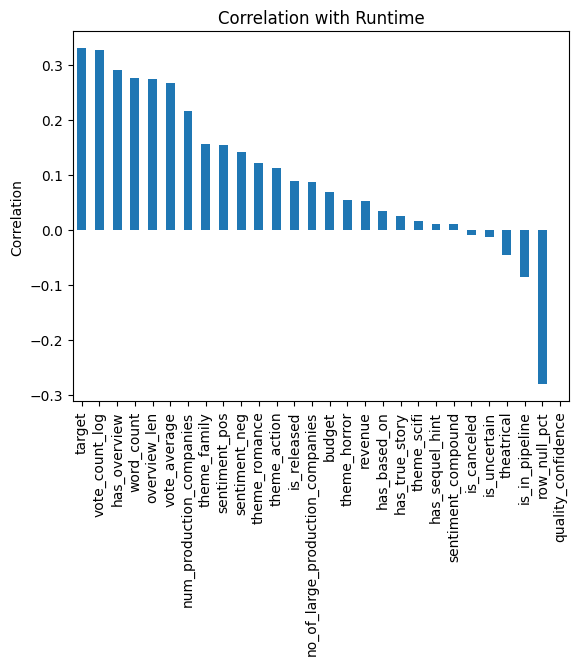

In [207]:
df['runtime'].describe()
df['runtime'].isnull().sum()
df['runtime'].dtype
print(df[df['runtime'] <= 0]['runtime'].count())
print(df[df['runtime'] > 400]['runtime'].count())
print(df[df['runtime'] <= 0]['runtime'].count())
print(df[df['runtime'] > 400]['runtime'].count())
numeric_df = df.select_dtypes(include=['number'])
corr_runtime = numeric_df.corr()['runtime'].sort_values(ascending=False)
print(corr_runtime)
import matplotlib.pyplot as plt
corr_runtime.drop('runtime').plot(kind='bar')
plt.title("Correlation with Runtime")
plt.ylabel("Correlation")
plt.show()

In [208]:
X_train['runtime'] = X_train['runtime'].where((X_train['runtime'] > 0) & (X_train['runtime'] <= 400), np.nan)
X_test['runtime'] = X_test['runtime'].where((X_test['runtime'] > 0) & (X_test['runtime'] <= 400), np.nan)

In [209]:
features = ['vote_count_log', 'quality_confidence', 'vote_average', 'is_released']

In [210]:
train_known = X_train[X_train['runtime'].notna()]
train_unknown = X_train[X_train['runtime'].isna()]

In [211]:
from sklearn.ensemble import RandomForestRegressor

In [212]:
model_runtime = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_runtime.fit(train_known[features], train_known['runtime'])

RandomForestRegressor(n_jobs=-1, random_state=42)

In [213]:
X_train.loc[X_train['runtime'].isna(), 'runtime'] = model_runtime.predict(train_unknown[features])

In [214]:
test_unknown = X_test[X_test['runtime'].isna()]
X_test.loc[X_test['runtime'].isna(), 'runtime'] = model_runtime.predict(test_unknown[features])

### Genres

In [215]:
X_train['all_genres'] = X_train['genres'].apply(lambda x: x.split(', ') if isinstance(x, str) else [])
X_test['all_genres'] = X_test['genres'].apply(lambda x: x.split(', ') if isinstance(x, str) else [])

In [216]:
X_train['has_genres'] = X_train['genres'].notna().astype(int)
X_test['has_genres'] = X_test['genres'].notna().astype(int)

In [217]:
X_train['num_genres'] = X_train['all_genres'].apply(len)
X_test['num_genres'] = X_test['all_genres'].apply(len)

In [218]:
genre_groups = {
    'action_group': ['Action', 'Adventure', 'Thriller', 'War'],
    'comedy_group': ['Comedy', 'Family'],
    'drama_group': ['Drama', 'History'],
    'romance_group': ['Romance'],
    'sci_fi_group': ['Science Fiction', 'Fantasy'],
    'dark_group': ['Horror', 'Crime', 'Mystery'],
    'other_group': ['Documentary', 'Music', 'TV Movie', 'Western', 'Animation']
}

In [219]:
def map_to_groups(genres):
    if not isinstance(genres, list):
        genres = []
    groups = []
    for group_name, group_genres in genre_groups.items():
        if any(g in genres for g in group_genres):
            groups.append(group_name)
    return groups

In [220]:
X_train['genre_groups_list'] = X_train['all_genres'].apply(map_to_groups)
X_test['genre_groups_list'] = X_test['all_genres'].apply(map_to_groups)

In [221]:
def fill_missing_groups(row):
    if row['has_genres']:
        return row['genre_groups_list']
    inferred = []
    if row['theme_action']:
        inferred.append('action_group')
    if row['theme_romance']:
        inferred.append('romance_group')
    if row['theme_scifi']:
        inferred.append('sci_fi_group')
    if row['theme_horror']:
        inferred.append('dark_group')
    if row['theme_family']:
        inferred.append('comedy_group')
    return inferred

In [222]:
train_mask = X_train['genres'].isna()
test_mask = X_test['genres'].isna()

In [223]:
X_train.loc[train_mask, 'genre_groups_list'] = X_train.loc[train_mask].apply(fill_missing_groups, axis=1)
X_test.loc[test_mask, 'genre_groups_list'] = X_test.loc[test_mask].apply(fill_missing_groups, axis=1)

In [224]:
mlb_genres = MultiLabelBinarizer()
group_matrix_train = mlb_genres.fit_transform(X_train['genre_groups_list'])
group_matrix_test = mlb_genres.transform(X_test['genre_groups_list'])

In [225]:
group_df_train = pd.DataFrame(group_matrix_train, columns=mlb_genres.classes_, index=X_train.index)
group_df_test = pd.DataFrame(group_matrix_test, columns=mlb_genres.classes_, index=X_test.index)

In [226]:
X_train = pd.concat([X_train, group_df_train], axis=1)
X_test = pd.concat([X_test, group_df_test], axis=1)

In [227]:
X_train.drop(columns=['genres',  'spoken_languages'], inplace=True)
X_test.drop(columns=['genres',  'spoken_languages'], inplace=True)

In [228]:
cols_to_drop = ['all_genres', 'genre_groups_list']
X_train.drop(columns=cols_to_drop, inplace=True)
X_test.drop(columns=cols_to_drop, inplace=True)

### Revenue & Budget

In [229]:
X_train['budget_known']  = (X_train['budget'] > 0).astype(int)
X_test['budget_known']   = (X_test['budget'] > 0).astype(int)

In [230]:
X_train['revenue_known'] = (X_train['revenue'] > 0).astype(int)
X_test['revenue_known']  = (X_test['revenue'] > 0).astype(int)

In [231]:
X_train['both_known'] = ((X_train['budget'] > 0) & (X_train['revenue'] > 0)).astype(int)
X_test['both_known']  = ((X_test['budget'] > 0) & (X_test['revenue'] > 0)).astype(int)

In [232]:
X_train['is_blockbuster'] = ((X_train['budget'] >= 20_000_000) & (X_train['revenue'] >= 50_000_000)).astype(int)
X_test['is_blockbuster']  = ((X_test['budget'] >= 20_000_000) & (X_test['revenue'] >= 50_000_000)).astype(int)

In [233]:
X_train['budget_log']  = np.log1p(X_train['budget'].fillna(0))
X_test['budget_log']   = np.log1p(X_test['budget'].fillna(0))

In [234]:
X_train['revenue_log'] = np.log1p(X_train['revenue'].fillna(0))
X_test['revenue_log']  = np.log1p(X_test['revenue'].fillna(0))

In [235]:
roi_mask_train = (X_train['budget'] > 0) & (X_train['revenue'] > 0)
roi_mask_test  = (X_test['budget'] > 0) & (X_test['revenue'] > 0)

In [236]:
X_train['roi'] = np.where(roi_mask_train, (X_train['revenue'] - X_train['budget']) / X_train['budget'], np.nan)
X_test['roi']  = np.where(roi_mask_test,  (X_test['revenue']  - X_test['budget'])  / X_test['budget'],  np.nan)

In [237]:
roi_median = X_train['roi'].median()
X_train['roi'] = X_train['roi'].fillna(roi_median)
X_test['roi']  = X_test['roi'].fillna(roi_median)

In [238]:
X_train.drop(columns=['budget', 'revenue'], inplace=True)
X_test.drop(columns=['budget', 'revenue'], inplace=True)

In [239]:
revenue_log_median = X_train['revenue_log'].median()
X_train['revenue_log'] = X_train['revenue_log'].fillna(revenue_log_median)
X_test['revenue_log']  = X_test['revenue_log'].fillna(revenue_log_median)

In [240]:
print(f"Nulls in X_train: {X_train.isnull().sum().sum()}")
print(f"Nulls in X_test:  {X_test.isnull().sum().sum()}")

Nulls in X_train: 0
Nulls in X_test:  0


In [241]:
print(X_train.dtypes.value_counts())

int64      42
float64    15
bool        6
Name: count, dtype: int64


In [242]:
print(" object columns if found :")


print(X_train.select_dtypes(include='object').columns.tolist())


 object columns if found :
[]


In [243]:
print(f"Nulls in X_train: {X_train.isnull().sum().sum()}")

print(f"Nulls in X_test:  {X_test.isnull().sum().sum()}")

Nulls in X_train: 0
Nulls in X_test:  0


In [244]:
print(f"X_train shape: {X_train.shape}")

print(f"X_test shape:  {X_test.shape}")

X_train shape: (838658, 63)
X_test shape:  (209665, 63)


In [245]:
null_cols_train = X_train.isnull().sum()
null_cols_train = null_cols_train[null_cols_train > 0].sort_values(ascending=False)

In [246]:
print("Columns with nulls in X_train:")
print(null_cols_train)

Columns with nulls in X_train:
Series([], dtype: int64)


In [247]:
null_cols_test = X_test.isnull().sum()
null_cols_test = null_cols_test[null_cols_test > 0].sort_values(ascending=False)

In [248]:
print("\nColumns with nulls in X_test:")

print(null_cols_test)



Columns with nulls in X_test:
Series([], dtype: int64)


# Feature Analysis

In [249]:
from sklearn.feature_selection import mutual_info_classif, f_classif
import matplotlib.pyplot as plt

###Mutual Information

In [250]:
print(" Mutual Information...")
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)


 Mutual Information...


In [251]:
print(mi_series)

vote_count_log        0.242551
vote_average          0.196001
row_null_pct          0.172084
budget_log            0.144556
other                 0.144225
                        ...   
is_canceled           0.000186
meta_null_count       0.000149
theme_scifi           0.000000
quality_confidence    0.000000
has_sequel_hint       0.000000
Length: 63, dtype: float64


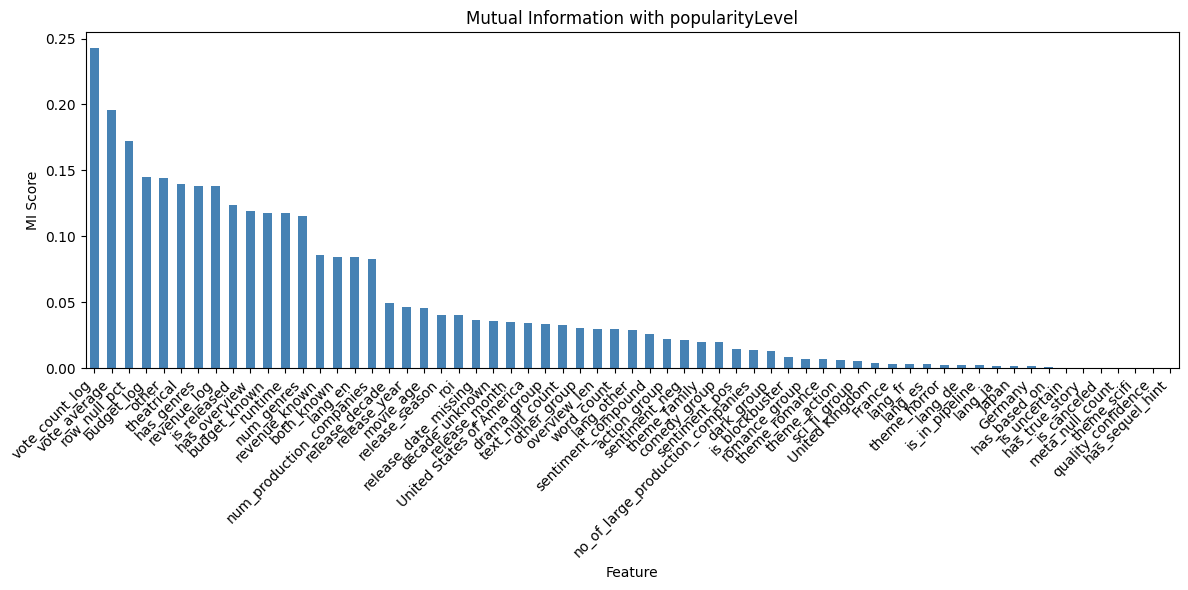

In [252]:
fig, ax = plt.subplots(figsize=(12, 6))
mi_series.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Mutual Information with popularityLevel')
ax.set_ylabel('MI Score')
ax.set_xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Anova (F-SCORE)

In [253]:
print(" ANOVA F-scores")
f_scores, p_values = f_classif(X_train, y_train)

f_series = pd.Series(f_scores, index=X_train.columns).sort_values(ascending=False)
p_series = pd.Series(p_values, index=X_train.columns)

 ANOVA F-scores


In [254]:
f_df = pd.DataFrame ({
    'F_score'  : f_series,
    'p_value'  : p_series,
    'significant': p_series < 0.05
}).round(4)



In [255]:
print (f_df)

                              F_score  p_value  significant
France                      1244.5241      0.0         True
Germany                      363.5417      0.0         True
Japan                       1058.6778      0.0         True
United Kingdom              2001.4895      0.0         True
United States of America   22970.9861      0.0         True
...                               ...      ...          ...
theme_romance               2000.8379      0.0         True
theme_scifi                  110.7706      0.0         True
vote_average               69315.0086      0.0         True
vote_count_log            456213.7300      0.0         True
word_count                  5571.5469      0.0         True

[63 rows x 3 columns]


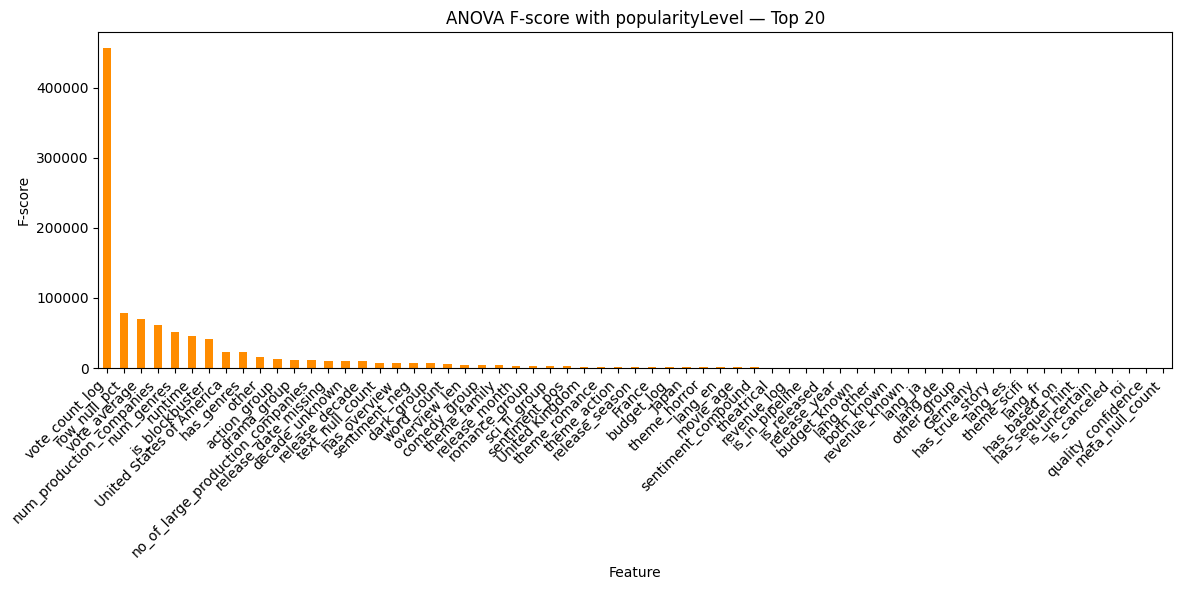

In [256]:
fig, ax = plt.subplots(figsize=(12, 6))
f_series.plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('ANOVA F-score with popularityLevel — Top 20')
ax.set_ylabel('F-score')
ax.set_xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


###inter-feature correlation

In [257]:
print("inter-feature correlation...")

corr_matrix = X_train.corr(numeric_only=True).abs()

inter-feature correlation...


In [258]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

In [259]:
high_corr_pairs = upper.stack().reset_index()
high_corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

In [260]:
high_corr_pairs = high_corr_pairs[
    high_corr_pairs['Correlation'] > 0.85
].sort_values(by='Correlation', ascending=False)

In [261]:
print(f"Highly correlated pairs (|r| > 0.85): {len(high_corr_pairs)}")

print(high_corr_pairs.to_string(index=False))


Highly correlated pairs (|r| > 0.85): 15
           Feature_1       Feature_2  Correlation
release_date_missing  decade_unknown     1.000000
        has_overview text_null_count     1.000000
       revenue_known      both_known     0.999912
release_date_missing  release_decade     0.999333
      release_decade  decade_unknown     0.999333
        overview_len      word_count     0.994495
         is_released  is_in_pipeline     0.991167
         is_released     revenue_log     0.964630
      is_in_pipeline     revenue_log     0.956169
         is_released    budget_known     0.946410
      is_in_pipeline    budget_known     0.937449
        budget_known     revenue_log     0.914255
          both_known      budget_log     0.898073
       revenue_known      budget_log     0.897931
             lang_ja           Japan     0.867940


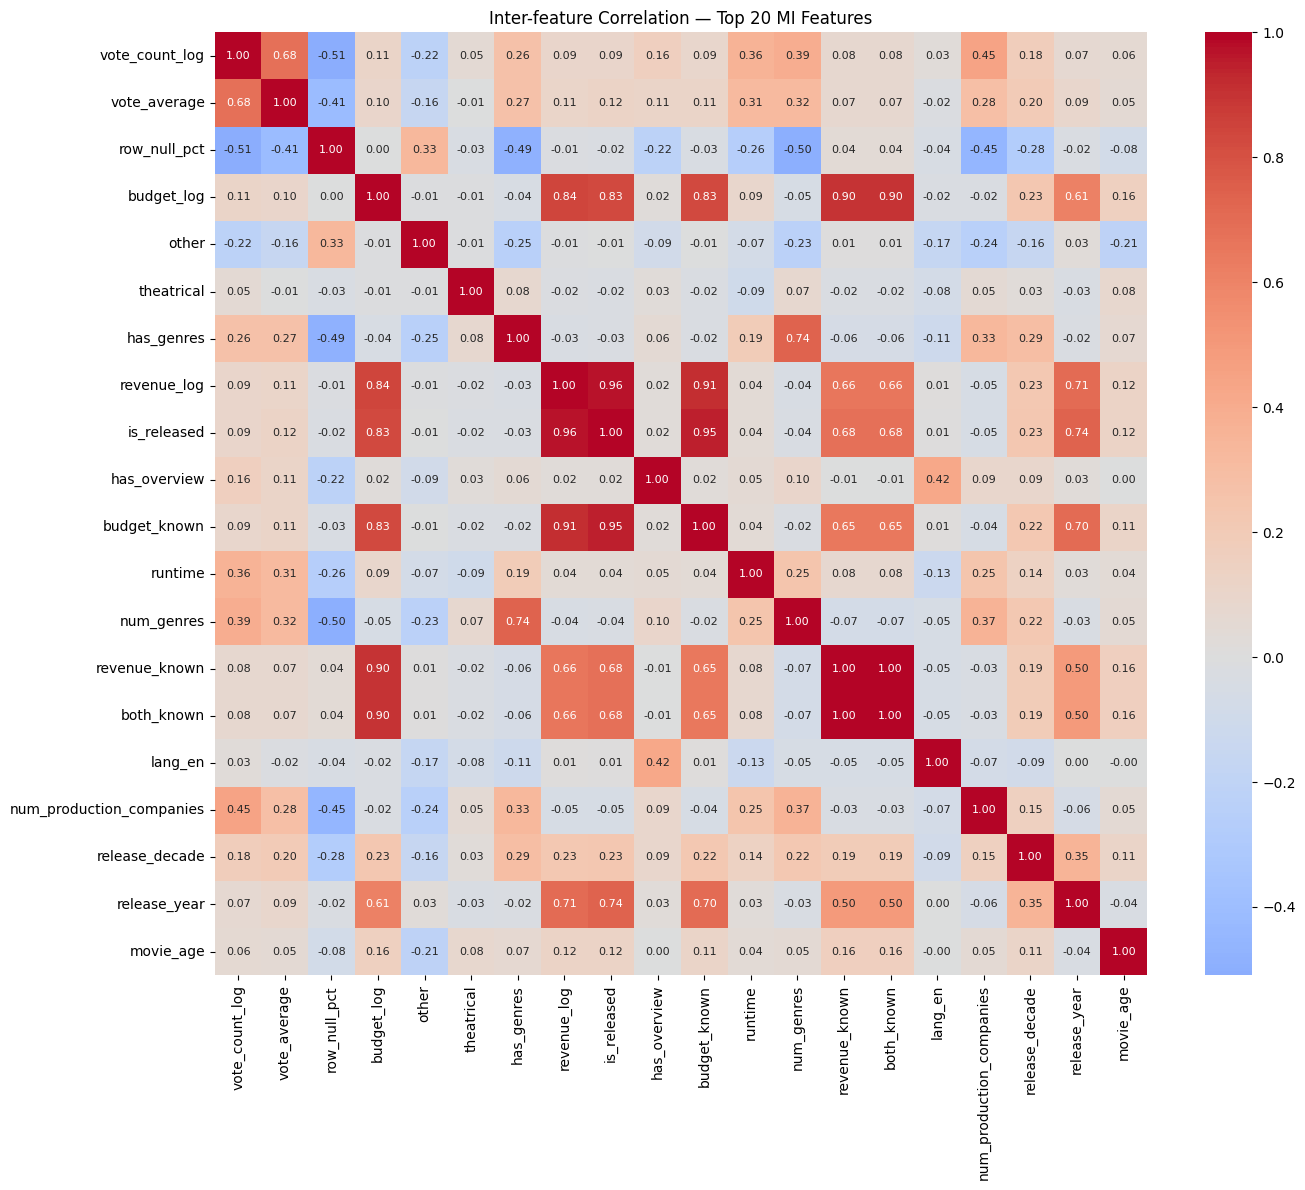

In [262]:
# Heatmap of top 20 features only (full matrix too large)
top20_features = mi_series.head(20).index.tolist()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    X_train[top20_features].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Inter-feature Correlation — Top 20 MI Features')
plt.tight_layout()
plt.show()

###Analysis Summary

In [263]:
print("\Feature Analysis Summary")

summary = pd.DataFrame({
    'MI_score' : mi_series,
    'F_score'  : f_series,
}).round(4)

\Feature Analysis Summary


In [264]:
summary['MI_norm'] = (summary['MI_score'] - summary['MI_score'].min()) / (summary['MI_score'].max() - summary['MI_score'].min())


In [265]:
summary['F_norm'] = (summary['F_score'] - summary['F_score'].min()) / (summary['F_score'].max() - summary['F_score'].min())


In [266]:
summary['consensus'] = (summary['MI_norm'] + summary['F_norm']) / 2


In [267]:
summary = summary.sort_values('consensus', ascending=False)

In [268]:
print("features by consensus (MI + F-score):")

print(summary[['MI_score', 'F_score', 'consensus']].round(4))

features by consensus (MI + F-score):
                    MI_score      F_score  consensus
vote_count_log        0.2426  456213.7300     1.0000
vote_average          0.1960   69315.0086     0.4799
row_null_pct          0.1721   78347.3582     0.4406
other                 0.1442   15394.4681     0.3141
has_genres            0.1383   22594.1292     0.3098
...                      ...          ...        ...
is_canceled           0.0002       9.1940     0.0004
theme_scifi           0.0000     110.7706     0.0001
has_sequel_hint       0.0000      19.8471     0.0000
meta_null_count       0.0001          NaN        NaN
quality_confidence    0.0000          NaN        NaN

[63 rows x 3 columns]


In [269]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1048323 entries, 0 to 1048572
Data columns (total 39 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   theatrical                        1048323 non-null  int64  
 1   vote_average                      1048323 non-null  float64
 2   release_date                      900555 non-null   object 
 3   revenue                           1048323 non-null  int64  
 4   runtime                           1048323 non-null  int64  
 5   budget                            1048323 non-null  int64  
 6   genres                            707706 non-null   object 
 7   production_countries              604012 non-null   object 
 8   spoken_languages                  627920 non-null   object 
 9   row_null_pct                      1048323 non-null  float64
 10  target                            1048323 non-null  int64  
 11  vote_count_log                    1048323 

In [270]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 838658 entries, 279932 to 969941
Data columns (total 63 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   theatrical                        838658 non-null  int64  
 1   vote_average                      838658 non-null  float64
 2   runtime                           838658 non-null  float64
 3   row_null_pct                      838658 non-null  float64
 4   vote_count_log                    838658 non-null  float64
 5   lang_de                           838658 non-null  bool   
 6   lang_en                           838658 non-null  bool   
 7   lang_es                           838658 non-null  bool   
 8   lang_fr                           838658 non-null  bool   
 9   lang_ja                           838658 non-null  bool   
 10  lang_other                        838658 non-null  bool   
 11  is_released                       838658 non-null  i

# Feature Selection

In [271]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from lightgbm import LGBMClassifier
from scipy.stats import spearmanr

In [272]:
k=20

####MI

In [273]:
print("Mutual Information")

mi_selector = SelectKBest(mutual_info_classif, k='all')

mi_selector.fit(X_train, y_train)

Mutual Information


SelectKBest(k='all',
            score_func=<function mutual_info_classif at 0x7c58d91fab60>)

In [274]:
mi_scores = pd.Series(
    mi_selector.scores_,
    index=X_train.columns
).fillna(0)


In [275]:
mi_top_k = mi_scores.sort_values(ascending=False).head(k).index.tolist()

In [276]:
print(f"Top {k}:")
print(mi_top_k)

Top 20:
['vote_count_log', 'vote_average', 'row_null_pct', 'budget_log', 'other', 'theatrical', 'has_genres', 'revenue_log', 'is_released', 'has_overview', 'budget_known', 'runtime', 'num_genres', 'revenue_known', 'both_known', 'lang_en', 'num_production_companies', 'release_decade', 'release_year', 'movie_age']


####lightGBM feature importance

In [277]:
print("LightGBM Feature Importance")

lgbm_fs = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)



LightGBM Feature Importance


In [278]:
sample_idx = np.random.RandomState(42).choice(len(X_train), size=min(100_000, len(X_train)), replace=False)

lgbm_fs.fit(X_train.iloc[sample_idx], y_train.iloc[sample_idx])


LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=200,
               n_jobs=-1, random_state=42, verbose=-1)

In [279]:
lgbm_scores = pd.Series(
    lgbm_fs.booster_.feature_importance(importance_type='gain'),
    index=X_train.columns
).fillna(0)

In [280]:
lgbm_top_k = lgbm_scores.sort_values(ascending=False).head(k).index.tolist()


In [281]:

print(f"Top {k}:")
print(lgbm_top_k)

Top 20:
['vote_count_log', 'release_year', 'runtime', 'row_null_pct', 'vote_average', 'release_month', 'budget_log', 'roi', 'overview_len', 'num_genres', 'word_count', 'sentiment_compound', 'sentiment_pos', 'sentiment_neg', 'num_production_companies', 'revenue_log', 'movie_age', 'lang_en', 'release_season', 'romance_group']


####Spearman Rank correlation

In [282]:
print("Spearman Rank Correlation")

spearman_scores= {}

Spearman Rank Correlation


In [283]:
for col in X_train.columns:
    corr, _ = spearmanr(X_train[col], y_train)
    spearman_scores[col] = abs(corr)

In [284]:
spearman_series = pd.Series(spearman_scores).fillna(0)
print(f"Top 5: {spearman_series.head(5).index.tolist()}")

Top 5: ['theatrical', 'vote_average', 'runtime', 'row_null_pct', 'vote_count_log']


In [285]:
spearman_top_k = (
    spearman_series
    .sort_values(ascending=False)
    .head(k)
    .index
    .tolist()
)

In [286]:
print(f"Top {k}:")
print(spearman_top_k)

Top 20:
['vote_count_log', 'vote_average', 'row_null_pct', 'runtime', 'num_genres', 'num_production_companies', 'roi', 'revenue_log', 'budget_log', 'has_genres', 'United States of America', 'other', 'drama_group', 'decade_unknown', 'release_date_missing', 'sentiment_neg', 'action_group', 'word_count', 'overview_len', 'no_of_large_production_companies']


In [287]:
print("Overlap Analysis")


Overlap Analysis


####Consensus scores

In [288]:
print(f"MI ∩ LGBM:      {len(set(mi_top_k) & set(lgbm_top_k))}")
print(f"MI ∩ Spearman:  {len(set(mi_top_k) & set(spearman_top_k))}")
print(f"LGBM ∩ Spearman:{len(set(lgbm_top_k) & set(spearman_top_k))}")

MI ∩ LGBM:      11
MI ∩ Spearman:  10
LGBM ∩ Spearman:12


In [289]:
all_three = (
    set(mi_top_k)
    & set(lgbm_top_k)
    & set(spearman_top_k)
)

In [290]:
print(f"All 3 agree:    {len(all_three)}")
print(sorted(all_three))

All 3 agree:    8
['budget_log', 'num_genres', 'num_production_companies', 'revenue_log', 'row_null_pct', 'runtime', 'vote_average', 'vote_count_log']


In [291]:
"""

Weighed importances so that :
 - LightGBM importance is strongest
 - Spearman is order-aware
 - ANOVA has the weakest influence

"""

'\n\nWeighed importances so that :\n - LightGBM importance is strongest\n - Spearman is order-aware\n - ANOVA has the weakest influence\n\n'

In [292]:
print("Building Consensus Scores")


Building Consensus Scores


In [293]:
consensus = pd.DataFrame({
    'MI_score': mi_scores,
    'LGBM_score': lgbm_scores,
    'Spearman_score': spearman_scores
}).fillna(0)


In [294]:
# Normalize each score to [0,1]
for col in consensus.columns:

    min_val = consensus[col].min()
    max_val = consensus[col].max()

    consensus[col + '_norm'] = ((consensus[col] - min_val)/ (max_val - min_val + 1e-9) )


In [295]:
# Weighted consensus
consensus['consensus_score'] = (0.35 * consensus['MI_score_norm'] +0.45 * consensus['LGBM_score_norm'] +0.20 * consensus['Spearman_score_norm'])

In [296]:
consensus = consensus.sort_values(
    'consensus_score',
    ascending=False
)

####Final Feature Selection

In [297]:
SELECTED_FEATURES = consensus.head(k).index.tolist()


In [298]:
if ('row_null_pct' in X_train.columns and 'row_null_pct' not in SELECTED_FEATURES):
    SELECTED_FEATURES[-1] = 'row_null_pct'


In [299]:
print(" Final Selected Features:")
print(SELECTED_FEATURES)


 Final Selected Features:
['vote_count_log', 'vote_average', 'row_null_pct', 'runtime', 'budget_log', 'revenue_log', 'num_genres', 'has_genres', 'other', 'num_production_companies', 'has_overview', 'theatrical', 'is_released', 'roi', 'budget_known', 'United States of America', 'lang_en', 'revenue_known', 'release_year', 'both_known']


In [300]:
X_train_fs = X_train[SELECTED_FEATURES].copy()

X_test_fs  = X_test[SELECTED_FEATURES].copy()


In [301]:
print("\ Shape After Feature Selection:")

print("X_train_fs:", X_train_fs.shape)
print("X_test_fs :", X_test_fs.shape)

\ Shape After Feature Selection:
X_train_fs: (838658, 20)
X_test_fs : (209665, 20)


####Consistency check with MS1

In [302]:
# checking consistency with milestone 1 (that MS2 features are a subset of MS1 / that they align)
ms1_features = ['vote_count_log', 'release_year', 'runtime',
                'vote_average', 'revenue_log', 'release_month',
                'num_genres', 'num_production_companies', 'roi',
                'overview_len', 'release_decade', 'other_group',
                'United States of America', 'sentiment_pos',
                'sentiment_neg', 'lang_en', 'lang_ja', 'sentiment_compound',
                'Japan', 'romance_group', 'lang_other', 'release_season',
                'drama_group', 'action_group', 'comedy_group', 'other',
                'no_of_large_production_companies', 'lang_es', 'has_genres',
                'dark_group', 'France', 'United Kingdom', 'budget_known',
                'Germany', 'theatrical', 'sci_fi_group', 'lang_fr']

In [303]:
overlap = set(SELECTED_FEATURES) & set(ms1_features)

In [304]:
print(f"CONSISTENCY CHECK")

print(f"  MS1 features: {len(ms1_features)}")
print(f"  MS2 features: {len(SELECTED_FEATURES)}")

CONSISTENCY CHECK
  MS1 features: 37
  MS2 features: 20


In [305]:
print(f"  Overlap: {len(overlap)} features ({100*len(overlap)/len(SELECTED_FEATURES):.0f}%)")
print(f"  Shared: {sorted(overlap)}")

  Overlap: 14 features (70%)
  Shared: ['United States of America', 'budget_known', 'has_genres', 'lang_en', 'num_genres', 'num_production_companies', 'other', 'release_year', 'revenue_log', 'roi', 'runtime', 'theatrical', 'vote_average', 'vote_count_log']


In [306]:
print(f"  Only in MS2: {sorted(set(SELECTED_FEATURES) - set(ms1_features))}")
print(f"  Only in MS1: {sorted(set(ms1_features) - set(SELECTED_FEATURES))}")

  Only in MS2: ['both_known', 'budget_log', 'has_overview', 'is_released', 'revenue_known', 'row_null_pct']
  Only in MS1: ['France', 'Germany', 'Japan', 'United Kingdom', 'action_group', 'comedy_group', 'dark_group', 'drama_group', 'lang_es', 'lang_fr', 'lang_ja', 'lang_other', 'no_of_large_production_companies', 'other_group', 'overview_len', 'release_decade', 'release_month', 'release_season', 'romance_group', 'sci_fi_group', 'sentiment_compound', 'sentiment_neg', 'sentiment_pos']


####safety checks

In [307]:
# ── safety checks

mi_scores = mi_scores if isinstance(mi_scores, pd.Series) else pd.Series(mi_scores)
lgbm_scores = lgbm_scores if isinstance(lgbm_scores, pd.Series) else pd.Series(lgbm_scores)
spearman_series = spearman_series if isinstance(spearman_series, pd.Series) else pd.Series(spearman_series)


In [308]:
mi_sorted = mi_scores.sort_values(ascending=False).head(20)
lgbm_sorted = lgbm_scores.sort_values(ascending=False).head(20)
spearman_sorted = spearman_series.sort_values(ascending=False).head(20)


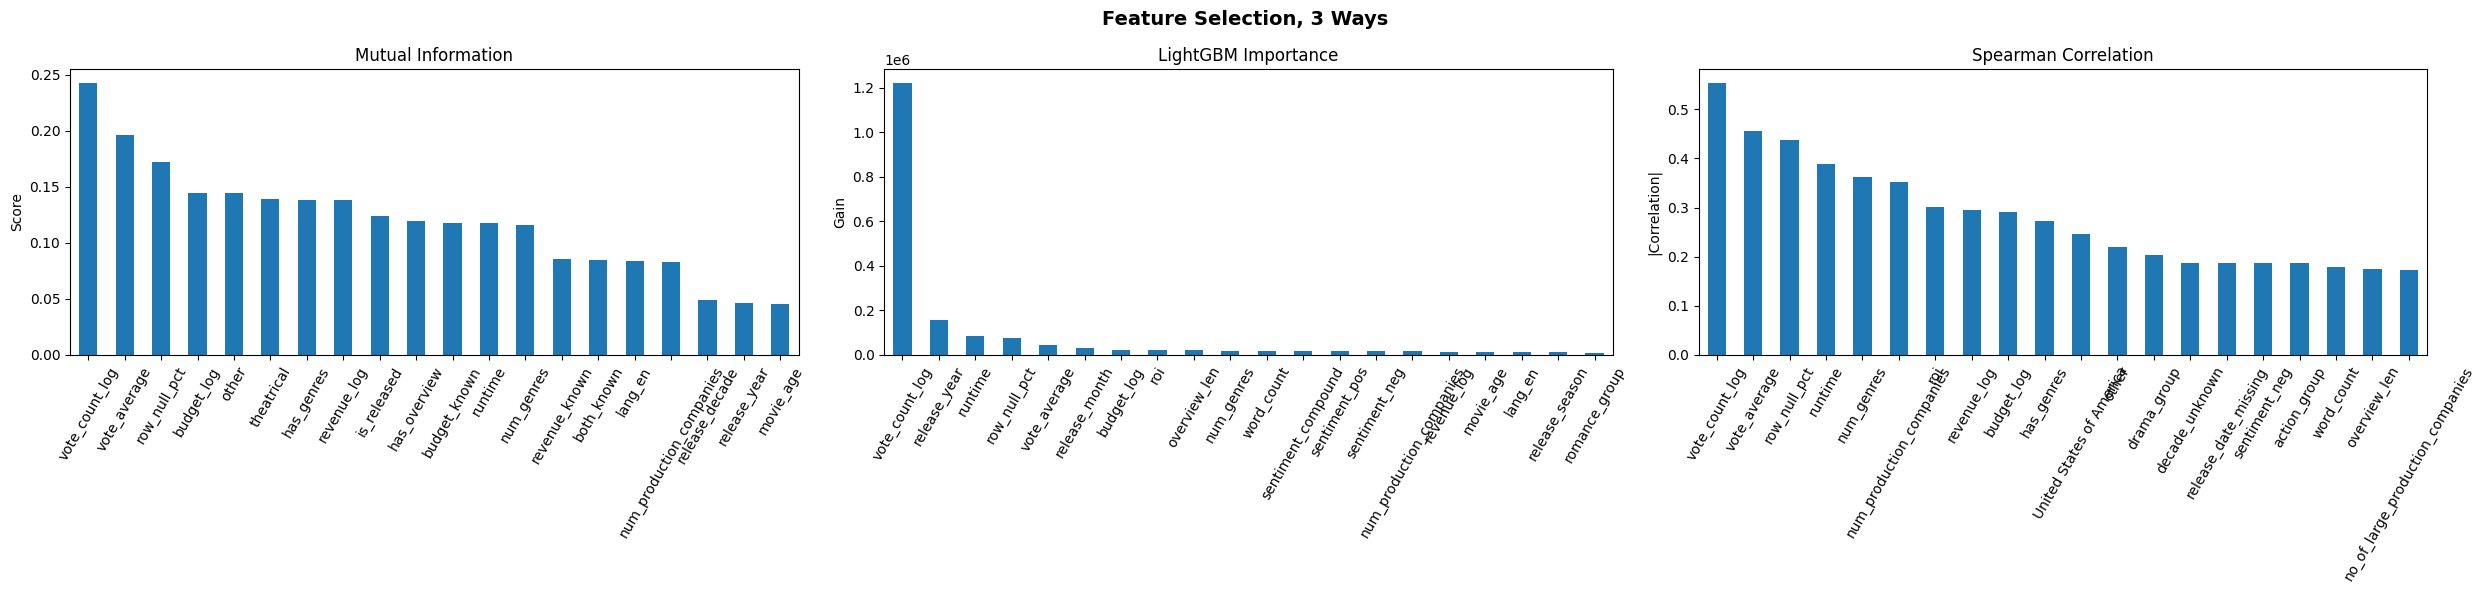

In [309]:
fig, axes = plt.subplots(1, 3, figsize=(25, 6))
mi_sorted.plot(kind='bar', ax=axes[0])
axes[0].set_title('Mutual Information')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=60)

lgbm_sorted.plot(kind='bar', ax=axes[1])
axes[1].set_title('LightGBM Importance')
axes[1].set_ylabel('Gain')
axes[1].tick_params(axis='x', rotation=60)

spearman_sorted.plot(kind='bar', ax=axes[2])
axes[2].set_title('Spearman Correlation')
axes[2].set_ylabel('|Correlation|')
axes[2].tick_params(axis='x', rotation=60)

plt.suptitle('Feature Selection, 3 Ways', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#Class Imbalance Handling

In [310]:
print("Original class distribution:")
orig_dist = pd.Series(y_train).value_counts().sort_index()
print(orig_dist)



Original class distribution:
target
0    646356
1    117553
2     62352
3     12397
Name: count, dtype: int64


In [311]:
from sklearn.preprocessing      import StandardScaler

In [312]:
# Scale before resampling (fit on training, apply everywhere)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fs)
X_test_scaled  = scaler.transform(X_test_fs)


In [313]:
# tried resampling with ADASYN, models found to be overshooting

'''
# Resampling instead of vanilla SMOTE
from imblearn.over_sampling  import ADASYN
from imblearn.under_sampling import RandomUnderSampler

print("Original distribution:")
print(pd.Series(y_train).value_counts().sort_index())

# Undersampling Very Low
under = RandomUnderSampler(
    sampling_strategy={0: 100_000},
    random_state=42
)
X_under_temp, y_under_temp = under.fit_resample(X_train_scaled, y_train)
print("\nAfter undersampling Very Low:")
print(pd.Series(y_under_temp).value_counts().sort_index())

print(pd.Series(y_under_temp).value_counts())

adasyn = ADASYN(
    sampling_strategy={
        2: 80_000,
        3: 60_000
    },
    random_state=42,
    n_neighbors=5
)
X_resampled, y_resampled = adasyn.fit_resample(X_under_temp, y_under_temp)

print("\nFinal resampled distribution:")
print(pd.Series(y_resampled).value_counts().sort_index())
print(f"\nFinal training shape: {X_resampled.shape}")adasyn = ADASYN(
    sampling_strategy={
        2: 80_000,
        3: 60_000
    },
    random_state=42,
    n_neighbors=5
)
X_resampled, y_resampled = adasyn.fit_resample(X_under_temp, y_under_temp)

print("\nFinal resampled distribution:")
print(pd.Series(y_resampled).value_counts().sort_index())
print(f"\nFinal training shape: {X_resampled.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (data, title) in zip(axes, [
    (y_train,      'Original (imbalanced)'),
    (y_resampled,  'After ADASYN + Undersampling'),
]):
    counts = pd.Series(data).value_counts().sort_index()
    ax.bar(['Very Low','Low','Medium','High'], counts.values,
           color=['#4C72B0','#55A868','#C44E52','#8172B2'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + counts.max()*0.01, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()
'''

'\n# Resampling instead of vanilla SMOTE\nfrom imblearn.over_sampling  import ADASYN\nfrom imblearn.under_sampling import RandomUnderSampler\n\nprint("Original distribution:")\nprint(pd.Series(y_train).value_counts().sort_index())\n\n# Undersampling Very Low\nunder = RandomUnderSampler(\n    sampling_strategy={0: 100_000},\n    random_state=42\n)\nX_under_temp, y_under_temp = under.fit_resample(X_train_scaled, y_train)\nprint("\nAfter undersampling Very Low:")\nprint(pd.Series(y_under_temp).value_counts().sort_index())\n\nprint(pd.Series(y_under_temp).value_counts())\n\nadasyn = ADASYN(\n    sampling_strategy={\n        2: 80_000,\n        3: 60_000\n    },\n    random_state=42,\n    n_neighbors=5\n)\nX_resampled, y_resampled = adasyn.fit_resample(X_under_temp, y_under_temp)\n\nprint("\nFinal resampled distribution:")\nprint(pd.Series(y_resampled).value_counts().sort_index())\nprint(f"\nFinal training shape: {X_resampled.shape}")adasyn = ADASYN(\n    sampling_strategy={\n        2: 80_

####ADASYN + undersampling

In [314]:
# trying ADASYN again, fixing the hierarchy correctly
from imblearn.over_sampling  import ADASYN
from imblearn.under_sampling import RandomUnderSampler

In [315]:
print("Original distribution (y_train):")
orig = pd.Series(y_train).value_counts().sort_index()
print(orig)
print(f"Imbalance ratio: {orig.max()/orig.min():.1f}:1")

Original distribution (y_train):
target
0    646356
1    117553
2     62352
3     12397
Name: count, dtype: int64
Imbalance ratio: 52.1:1


In [316]:
under = RandomUnderSampler(
    sampling_strategy={
        0: 80_000,
        1: 60_000,
        2: 45_000,
    },
    random_state=42
)

In [317]:
X_under_temp, y_under_temp = under.fit_resample(X_train_scaled, y_train)

In [318]:
print("After undersampling (before ADASYN):")
print(pd.Series(y_under_temp).value_counts().sort_index())

After undersampling (before ADASYN):
target
0    80000
1    60000
2    45000
3    12397
Name: count, dtype: int64


In [319]:
adasyn = ADASYN(
    sampling_strategy={3: 30_000},
    random_state=42,
    n_neighbors=5
)
X_resampled, y_resampled = adasyn.fit_resample(X_under_temp, y_under_temp)

In [320]:
print("Final resampled distribution:")

final_dist = pd.Series(y_resampled).value_counts().sort_index()
print(final_dist)
print(f"New imbalance ratio: {final_dist.max()/final_dist.min():.1f}:1")
print(f"Final training shape: {X_resampled.shape}")

Final resampled distribution:
target
0    80000
1    60000
2    45000
3    29835
Name: count, dtype: int64
New imbalance ratio: 2.7:1
Final training shape: (214835, 20)


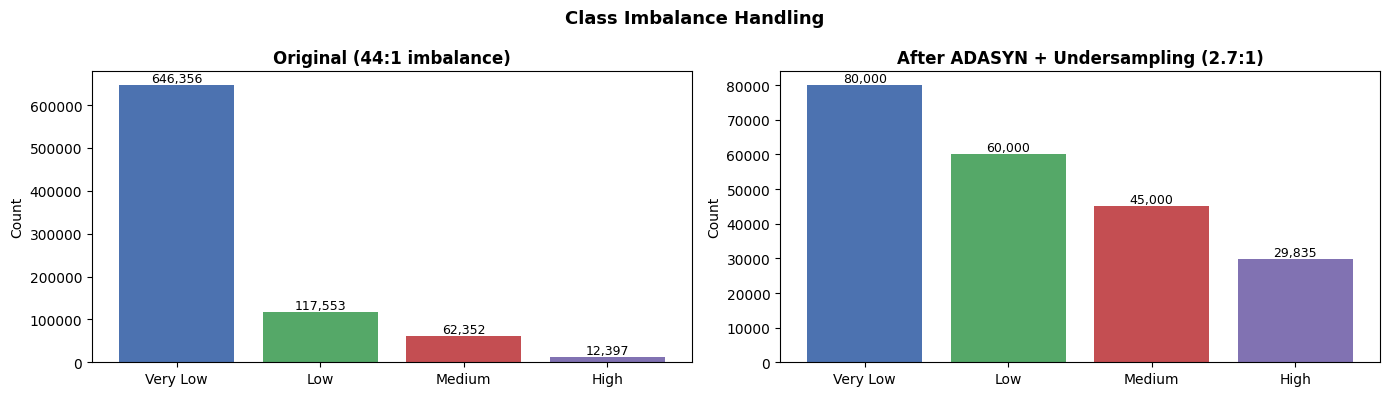

In [321]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

data_list = [y_train, y_resampled]
titles = ['Original (44:1 imbalance)', 'After ADASYN + Undersampling (2.7:1)']
labels = ['Very Low', 'Low', 'Medium', 'High']

for i in range(2):
    counts = pd.Series(data_list[i]).value_counts().sort_index()

    axes[i].bar(labels, counts.values,color=['#4C72B0','#55A868','#C44E52','#8172B2'])

    axes[i].set_title(titles[i], fontweight='bold')
    axes[i].set_ylabel('Count')

    for j, v in enumerate(counts.values):
        axes[i].text(j, v, f'{v:,}', ha='center', va='bottom', fontsize=9)


plt.suptitle('Class Imbalance Handling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



In [322]:
X_resampled    = X_resampled.astype('float32')
X_test_scaled  = X_test_scaled.astype('float32')
X_train_scaled = X_train_scaled.astype('float32')
print("Cast to float32 done")


Cast to float32 done


In [323]:
del X_under_temp, y_under_temp
del X_train_fs, X_test_fs
del X_train, X_test
del lgbm_fs
del model_runtime
gc.collect()
print("Cleanup done")


Cleanup done


# Training


In [324]:
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import (classification_report, f1_score,balanced_accuracy_score, cohen_kappa_score,ConfusionMatrixDisplay)
import time

In [325]:
RANDOM_STATE  = 42
CV_FOLDS      = 5
SCORING       = 'f1_macro'
N_JOBS        = -1

In [326]:
CLASS_NAMES = ['Very Low', 'Low', 'Medium', 'High']


In [327]:


def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    y_pred = model.predict(X_te)
    train_pred = model.predict(X_tr)

    results = {
        'Model':            name,
        'Train Acc':        round(accuracy_score(y_tr, train_pred), 4),
        'Test Acc':         round(accuracy_score(y_te, y_pred),     4),
        'Macro F1':         round(f1_score(y_te, y_pred, average='macro'), 4),
        'Balanced Acc':     round(balanced_accuracy_score(y_te, y_pred),   4),
        'Kappa':            round(cohen_kappa_score(y_te, y_pred),         4),
        'Weighted Kappa': round(cohen_kappa_score(y_te, y_pred, weights='quadratic'), 4),
        'Train Time (s)':   round(elapsed, 1),
        '_y_pred':          y_pred,
        '_model':           model,
    }

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Train Acc:    {results['Train Acc']}")
    print(f"  Test Acc:     {results['Test Acc']}")
    print(f"  Macro F1:     {results['Macro F1']}")
    print(f"  Balanced Acc: {results['Balanced Acc']}")
    print(f"  Kappa:        {results['Kappa']}")
    print(f"  W-Kappa:      {results['Weighted Kappa']}")
    print(f"  Train time:   {results['Train Time (s)']}s")
    print(f"\n{classification_report(y_te, y_pred, target_names=CLASS_NAMES)}")

    return results

all_results = []

####Logisitc Rgression

In [328]:
from sklearn.metrics import accuracy_score

In [329]:

from sklearn.linear_model import SGDClassifier

lr_model = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0.0001,
    class_weight='balanced',
    max_iter=100,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    tol=1e-3
)


In [330]:
res_lr = evaluate_model('Logistic Regression (SGD)',
                         lr_model,
                         X_resampled, y_resampled,
                         X_test_scaled, y_test)


  Logistic Regression (SGD)
  Train Acc:    0.626
  Test Acc:     0.7411
  Macro F1:     0.5415
  Balanced Acc: 0.6452
  Kappa:        0.3996
  W-Kappa:      0.7002
  Train time:   1.4s

              precision    recall  f1-score   support

    Very Low       0.92      0.83      0.87    161589
         Low       0.29      0.38      0.33     29388
      Medium       0.46      0.50      0.48     15588
        High       0.34      0.87      0.49      3100

    accuracy                           0.74    209665
   macro avg       0.50      0.65      0.54    209665
weighted avg       0.79      0.74      0.76    209665



In [331]:
all_results.append(res_lr)

####Random Forest

In [332]:


from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)




In [333]:
res_rf = evaluate_model('Random Forest',
                         rf_model,
                         X_resampled, y_resampled,
                         X_test_scaled, y_test)


  Random Forest
  Train Acc:    0.7751
  Test Acc:     0.7494
  Macro F1:     0.6473
  Balanced Acc: 0.7267
  Kappa:        0.4599
  W-Kappa:      0.7065
  Train time:   38.6s

              precision    recall  f1-score   support

    Very Low       0.94      0.78      0.85    161589
         Low       0.32      0.59      0.42     29388
      Medium       0.64      0.68      0.66     15588
        High       0.53      0.85      0.66      3100

    accuracy                           0.75    209665
   macro avg       0.61      0.73      0.65    209665
weighted avg       0.83      0.75      0.78    209665



In [334]:
all_results.append(res_rf)

####XG-Boost

In [335]:


from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    verbosity=0
)




In [336]:
res_xgb = evaluate_model('XGBoost',
                           xgb_model,
                           X_resampled, y_resampled,
                           X_test_scaled, y_test)


  XGBoost
  Train Acc:    0.7392
  Test Acc:     0.7926
  Macro F1:     0.6887
  Balanced Acc: 0.7211
  Kappa:        0.5119
  W-Kappa:      0.7544
  Train time:   45.3s

              precision    recall  f1-score   support

    Very Low       0.93      0.85      0.89    161589
         Low       0.37      0.56      0.45     29388
      Medium       0.70      0.66      0.68     15588
        High       0.68      0.81      0.74      3100

    accuracy                           0.79    209665
   macro avg       0.67      0.72      0.69    209665
weighted avg       0.83      0.79      0.81    209665



In [337]:
all_results.append(res_xgb)

####LightGBM

In [338]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    verbose=-1
)




In [339]:
res_lgbm = evaluate_model('LightGBM',
                            lgbm_model,
                            X_resampled, y_resampled,
                            X_test_scaled, y_test)


  LightGBM
  Train Acc:    0.7703
  Test Acc:     0.7575
  Macro F1:     0.6646
  Balanced Acc: 0.7253
  Kappa:        0.4725
  W-Kappa:      0.7105
  Train time:   38.6s

              precision    recall  f1-score   support

    Very Low       0.94      0.79      0.86    161589
         Low       0.33      0.59      0.43     29388
      Medium       0.62      0.72      0.67     15588
        High       0.63      0.80      0.71      3100

    accuracy                           0.76    209665
   macro avg       0.63      0.73      0.66    209665
weighted avg       0.83      0.76      0.78    209665



In [340]:
all_results.append(res_lgbm)

In [341]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 13.3 MB/s eta 0:00:00


####CatBoost

In [342]:

from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    auto_class_weights='Balanced',
    random_seed=RANDOM_STATE,
    verbose=0,
    thread_count=N_JOBS
)

In [343]:
res_cat = evaluate_model('CatBoost',
                           cat_model,
                           X_resampled, y_resampled,
                           X_test_scaled, y_test)


  CatBoost
  Train Acc:    0.7199
  Test Acc:     0.7468
  Macro F1:     0.6485
  Balanced Acc: 0.7239
  Kappa:        0.4552
  W-Kappa:      0.7051
  Train time:   75.4s

              precision    recall  f1-score   support

    Very Low       0.94      0.78      0.85    161589
         Low       0.32      0.58      0.41     29388
      Medium       0.62      0.70      0.66     15588
        High       0.56      0.84      0.68      3100

    accuracy                           0.75    209665
   macro avg       0.61      0.72      0.65    209665
weighted avg       0.82      0.75      0.77    209665



In [344]:
all_results.append(res_cat)

####ExtraTreeClassifier

In [345]:


from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)




In [346]:
res_et = evaluate_model('Extra Trees',
                          et_model,
                          X_resampled, y_resampled,
                          X_test_scaled, y_test)


  Extra Trees
  Train Acc:    0.6934
  Test Acc:     0.7476
  Macro F1:     0.6279
  Balanced Acc: 0.6957
  Kappa:        0.4332
  W-Kappa:      0.7149
  Train time:   43.8s

              precision    recall  f1-score   support

    Very Low       0.92      0.80      0.86    161589
         Low       0.30      0.47      0.37     29388
      Medium       0.57      0.66      0.61     15588
        High       0.56      0.85      0.68      3100

    accuracy                           0.75    209665
   macro avg       0.59      0.70      0.63    209665
weighted avg       0.80      0.75      0.77    209665



In [347]:
all_results.append(res_et)

In [348]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.0 MB/s eta 0:00:00


In [349]:
"""
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ── 100k subsample for tuning ─────────────────────────────────────────────────
tune_idx = np.random.RandomState(42).choice(len(X_resampled), size=100_000, replace=False)
X_tune   = X_resampled[tune_idx]
y_tune   = np.array(y_resampled)[tune_idx]

cv_tune  = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def lgbm_objective(trial):
    # These 6 parameters have the highest impact on LightGBM accuracy
    params = {
        'n_estimators':       trial.suggest_int('n_estimators', 200, 600),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':         trial.suggest_int('num_leaves', 31, 127),
        'min_child_samples':  trial.suggest_int('min_child_samples', 10, 80),
        'subsample':          trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'class_weight': 'balanced',
        'random_state': RANDOM_STATE,
        'n_jobs': N_JOBS,
        'verbose': -1
    }
    model  = LGBMClassifier(**params)
    scores = cross_val_score(model, X_tune, y_tune,
                              cv=cv_tune, scoring='f1_macro', n_jobs=N_JOBS)
    return scores.mean()

print("Running Optuna — 20 trials on 100k subsample (~10–15 min)...")
study = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(lgbm_objective, n_trials=20, show_progress_bar=True)

print(f"\nBest CV Macro F1 : {study.best_value:.4f}")
print(f"Best parameters  :\n")
for k, v in study.best_params.items():
    print(f"   {k:<25} {v}")

# ── Train tuned model on full resampled data ──────────────────────────────────
lgbm_tuned = LGBMClassifier(
    **study.best_params,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    verbose=-1
)
res_tuned = evaluate_model(
    'LightGBM (Optuna-Tuned)',
    lgbm_tuned,
    X_resampled, y_resampled,
    X_test_scaled, y_test
)
all_results.append(res_tuned)

# ── Show what Optuna learned ──────────────────────────────────────────────────
trials_df = study.trials_dataframe().sort_values('value', ascending=False)
print("\nTop 5 trials:")
print(trials_df[['number','value'] + [c for c in trials_df.columns
      if c.startswith('params_')]].head(5).to_string(index=False))
"""

'\nimport optuna\noptuna.logging.set_verbosity(optuna.logging.WARNING)\nfrom sklearn.model_selection import StratifiedKFold, cross_val_score\n\n# ── 100k subsample for tuning ─────────────────────────────────────────────────\ntune_idx = np.random.RandomState(42).choice(len(X_resampled), size=100_000, replace=False)\nX_tune   = X_resampled[tune_idx]\ny_tune   = np.array(y_resampled)[tune_idx]\n\ncv_tune  = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)\n\ndef lgbm_objective(trial):\n    # These 6 parameters have the highest impact on LightGBM accuracy\n    params = {\n        \'n_estimators\':       trial.suggest_int(\'n_estimators\', 200, 600),\n        \'learning_rate\':      trial.suggest_float(\'learning_rate\', 0.01, 0.15, log=True),\n        \'num_leaves\':         trial.suggest_int(\'num_leaves\', 31, 127),\n        \'min_child_samples\':  trial.suggest_int(\'min_child_samples\', 10, 80),\n        \'subsample\':          trial.suggest_float(\'subsample\', 0.6, 1.0),\n

####Final Comparison Table

In [350]:
summary_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in all_results
])

In [351]:
summary_df['Overfit Gap'] = (summary_df['Train Acc'] - summary_df['Test Acc']).round(4)
summary_df = summary_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)


In [352]:
print("\n" + "="*80)
print("FINAL MODEL COMPARISON — sorted by Macro F1")
print("="*80)
print(summary_df.to_string(index=False))


FINAL MODEL COMPARISON — sorted by Macro F1
                    Model  Train Acc  Test Acc  Macro F1  Balanced Acc  Kappa  Weighted Kappa  Train Time (s)  Overfit Gap
                  XGBoost     0.7392    0.7926    0.6887        0.7211 0.5119          0.7544            45.3      -0.0534
                 LightGBM     0.7703    0.7575    0.6646        0.7253 0.4725          0.7105            38.6       0.0128
                 CatBoost     0.7199    0.7468    0.6485        0.7239 0.4552          0.7051            75.4      -0.0269
            Random Forest     0.7751    0.7494    0.6473        0.7267 0.4599          0.7065            38.6       0.0257
              Extra Trees     0.6934    0.7476    0.6279        0.6957 0.4332          0.7149            43.8      -0.0542
Logistic Regression (SGD)     0.6260    0.7411    0.5415        0.6452 0.3996          0.7002             1.4      -0.1151


In [353]:
best = summary_df.iloc[0]
print(f"\n★  BEST MODEL → {best['Model']}")
print(f"   Macro F1:     {best['Macro F1']}")
print(f"   Balanced Acc: {best['Balanced Acc']}")
print(f"   Kappa:        {best['Kappa']}")
print(f"   Overfit Gap:  {best['Overfit Gap']}")


★  BEST MODEL → XGBoost
   Macro F1:     0.6887
   Balanced Acc: 0.7211
   Kappa:        0.5119
   Overfit Gap:  -0.0534


In [354]:
best_pred = next(r['_y_pred'] for r in all_results if r['Model'] == best['Model'])


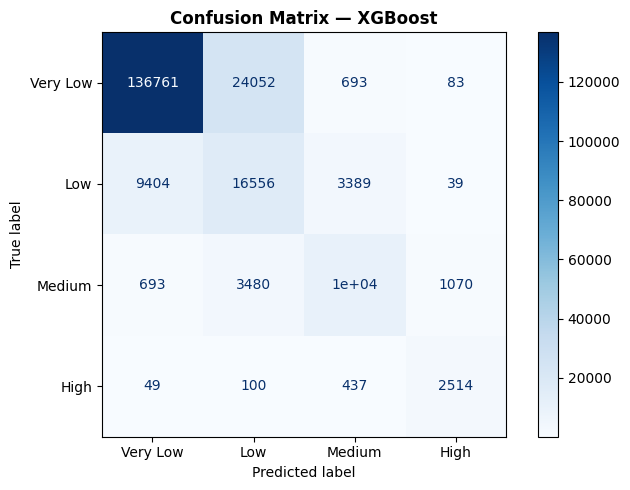

In [355]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred,
    display_labels=CLASS_NAMES,
    cmap='Blues', ax=ax
)

ax.set_title(f"Confusion Matrix — {best['Model']}", fontweight='bold')
plt.tight_layout()
plt.show()

####Experiment 2 : SMOTE

In [356]:
from imblearn.over_sampling  import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [357]:
under_smote = RandomUnderSampler(
    sampling_strategy={0: 80_000, 1: 60_000, 2: 45_000},
    random_state=42
)

In [358]:
X_under_smote, y_under_smote = under_smote.fit_resample(X_train_scaled, y_train)


In [359]:
smote = SMOTE(
    sampling_strategy={3: 30_000},
    random_state=42,
    k_neighbors=5
)

In [360]:
X_smote, y_smote = smote.fit_resample(X_under_smote, y_under_smote)
X_smote = X_smote.astype('float32')

In [361]:
print("SMOTE distribution:")
print(pd.Series(y_smote).value_counts().sort_index())
print(f"Shape: {X_smote.shape}")

SMOTE distribution:
target
0    80000
1    60000
2    45000
3    30000
Name: count, dtype: int64
Shape: (215000, 20)


In [362]:
del X_under_smote, y_under_smote
gc.collect()

29975

In [363]:
smote_results = []

Smote Results

In [364]:
for name, model in [
    ('LR [SMOTE]',      SGDClassifier(loss='log_loss', penalty='l2',
                                       class_weight='balanced',
                                       random_state=42, n_jobs=-1, max_iter=100)),
    ('LightGBM [SMOTE]', LGBMClassifier(n_estimators=500, learning_rate=0.05,
                                          num_leaves=63, subsample=0.8,
                                          colsample_bytree=0.8,
                                          class_weight='balanced',
                                          random_state=42, n_jobs=-1, verbose=-1)),
    ('XGBoost [SMOTE]',  XGBClassifier(n_estimators=500, learning_rate=0.05,
                                         max_depth=6, subsample=0.8,
                                         colsample_bytree=0.8,
                                         eval_metric='mlogloss',
                                         random_state=42, n_jobs=-1, verbosity=0)),
]:
    r = evaluate_model(name, model, X_smote, y_smote, X_test_scaled, y_test)
    smote_results.append(r)
    all_results.append(r)
    gc.collect()

del X_smote, y_smote
gc.collect()
print("SMOTE run complete.")


  LR [SMOTE]
  Train Acc:    0.6409
  Test Acc:     0.7389
  Macro F1:     0.5423
  Balanced Acc: 0.6422
  Kappa:        0.3984
  W-Kappa:      0.706
  Train time:   2.5s

              precision    recall  f1-score   support

    Very Low       0.92      0.82      0.87    161589
         Low       0.30      0.45      0.36     29388
      Medium       0.47      0.42      0.44     15588
        High       0.35      0.88      0.50      3100

    accuracy                           0.74    209665
   macro avg       0.51      0.64      0.54    209665
weighted avg       0.79      0.74      0.76    209665


  LightGBM [SMOTE]
  Train Acc:    0.7726
  Test Acc:     0.757
  Macro F1:     0.6694
  Balanced Acc: 0.7252
  Kappa:        0.4721
  W-Kappa:      0.7125
  Train time:   42.6s

              precision    recall  f1-score   support

    Very Low       0.94      0.79      0.86    161589
         Low       0.33      0.59      0.43     29388
      Medium       0.62      0.72      0.67     1

####Experiment 3 : NO SYNTHETIC ROWS

In [365]:
under_only = RandomUnderSampler(
    sampling_strategy={0: 80_000, 1: 60_000, 2: 45_000},
    random_state=42
)

In [366]:
X_under_only, y_under_only = under_only.fit_resample(X_train_scaled, y_train)
X_under_only = X_under_only.astype('float32')

In [367]:
print("No-synthetic distribution (undersampled only):")
print(pd.Series(y_under_only).value_counts().sort_index())
print(f"Shape: {X_under_only.shape}")

No-synthetic distribution (undersampled only):
target
0    80000
1    60000
2    45000
3    12397
Name: count, dtype: int64
Shape: (197397, 20)


In [368]:
nosyn_results = []

In [369]:
for name, model in [
    ('LR [No-Synthetic]',      SGDClassifier(loss='log_loss', penalty='l2',
                                              class_weight='balanced',
                                              random_state=42, n_jobs=-1, max_iter=100)),
    ('LightGBM [No-Synthetic]', LGBMClassifier(n_estimators=500, learning_rate=0.05,
                                                 num_leaves=63, subsample=0.8,
                                                 colsample_bytree=0.8,
                                                 class_weight='balanced',
                                                 random_state=42, n_jobs=-1, verbose=-1)),
    ('XGBoost [No-Synthetic]',  XGBClassifier(n_estimators=500, learning_rate=0.05,
                                                max_depth=6, subsample=0.8,
                                                colsample_bytree=0.8,
                                                eval_metric='mlogloss',
                                                random_state=42, n_jobs=-1, verbosity=0)),
]:
    r = evaluate_model(name, model, X_under_only, y_under_only, X_test_scaled, y_test)
    nosyn_results.append(r)
    all_results.append(r)
    gc.collect()


print("No-synthetic run complete.")


  LR [No-Synthetic]
  Train Acc:    0.6452
  Test Acc:     0.743
  Macro F1:     0.5955
  Balanced Acc: 0.6578
  Kappa:        0.4098
  W-Kappa:      0.6825
  Train time:   1.8s

              precision    recall  f1-score   support

    Very Low       0.92      0.82      0.87    161589
         Low       0.27      0.33      0.30     29388
      Medium       0.45      0.73      0.56     15588
        High       0.59      0.75      0.66      3100

    accuracy                           0.74    209665
   macro avg       0.56      0.66      0.60    209665
weighted avg       0.79      0.74      0.76    209665


  LightGBM [No-Synthetic]
  Train Acc:    0.7515
  Test Acc:     0.7557
  Macro F1:     0.6581
  Balanced Acc: 0.7308
  Kappa:        0.4699
  W-Kappa:      0.7108
  Train time:   63.9s

              precision    recall  f1-score   support

    Very Low       0.94      0.79      0.86    161589
         Low       0.33      0.59      0.43     29388
      Medium       0.62      0.70 

#Hyperparameter Tuning

In [370]:
import time
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

In [371]:

BASE_PARAMS = dict(
    learning_rate    = 0.05,
    max_depth        = 6,
    n_estimators     = 500,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)

In [372]:
hp_results = {}

#### n-estimators

In [373]:
hp1_results = []

for v in [100, 300, 500]:
    model = XGBClassifier(**{**BASE_PARAMS, 'n_estimators': v})

    t0 = time.time(); model.fit(X_under_only, y_under_only); train_time = round(time.time()-t0, 2)
    t0 = time.time(); y_pred = model.predict(X_test_scaled); test_time  = round(time.time()-t0, 4)

    acc   = round(accuracy_score(y_test, y_pred), 4)
    macro = round(f1_score(y_test, y_pred, average='macro'), 4)

    hp1_results.append({'n_estimators': v, 'Test Acc': acc, 'Macro F1': macro,
                        'Train Time': train_time, 'Test Time': test_time})
    print(f"  n_estimators={v:<5}  Acc={acc}  MacroF1={macro}  Train={train_time}s  Test={test_time}s")

hp_results['n_estimators'] = pd.DataFrame(hp1_results)

  n_estimators=100    Acc=0.7917  MacroF1=0.6966  Train=9.4s  Test=1.5491s
  n_estimators=300    Acc=0.7935  MacroF1=0.6996  Train=24.98s  Test=4.5937s
  n_estimators=500    Acc=0.7942  MacroF1=0.7001  Train=42.62s  Test=21.7958s


####max_depth

In [374]:
hp2_results = []

for v in [3, 6, 9]:
    model = XGBClassifier(**{**BASE_PARAMS, 'max_depth': v})

    t0 = time.time(); model.fit(X_under_only, y_under_only); train_time = round(time.time()-t0, 2)
    t0 = time.time(); y_pred = model.predict(X_test_scaled); test_time  = round(time.time()-t0, 4)

    acc   = round(accuracy_score(y_test, y_pred), 4)
    macro = round(f1_score(y_test, y_pred, average='macro'), 4)

    hp2_results.append({'max_depth': v, 'Test Acc': acc, 'Macro F1': macro,
                        'Train Time': train_time, 'Test Time': test_time})
    print(f"  max_depth={v:<5}  Acc={acc}  MacroF1={macro}  Train={train_time}s  Test={test_time}s")

hp_results['max_depth'] = pd.DataFrame(hp2_results)


  max_depth=3      Acc=0.789  MacroF1=0.6952  Train=30.09s  Test=5.4466s
  max_depth=6      Acc=0.7942  MacroF1=0.7001  Train=39.95s  Test=11.1147s
  max_depth=9      Acc=0.7905  MacroF1=0.6962  Train=53.32s  Test=13.6279s


####Results and Visualization

In [375]:
print("HP1 — n_estimators:")
print(hp_results['n_estimators'].to_string(index=False))
print("HP2 — max_depth:")
print(hp_results['max_depth'].to_string(index=False))

HP1 — n_estimators:
 n_estimators  Test Acc  Macro F1  Train Time  Test Time
          100    0.7917    0.6966        9.40     1.5491
          300    0.7935    0.6996       24.98     4.5937
          500    0.7942    0.7001       42.62    21.7958
HP2 — max_depth:
 max_depth  Test Acc  Macro F1  Train Time  Test Time
         3    0.7890    0.6952       30.09     5.4466
         6    0.7942    0.7001       39.95    11.1147
         9    0.7905    0.6962       53.32    13.6279


In [376]:
import matplotlib.pyplot as plt


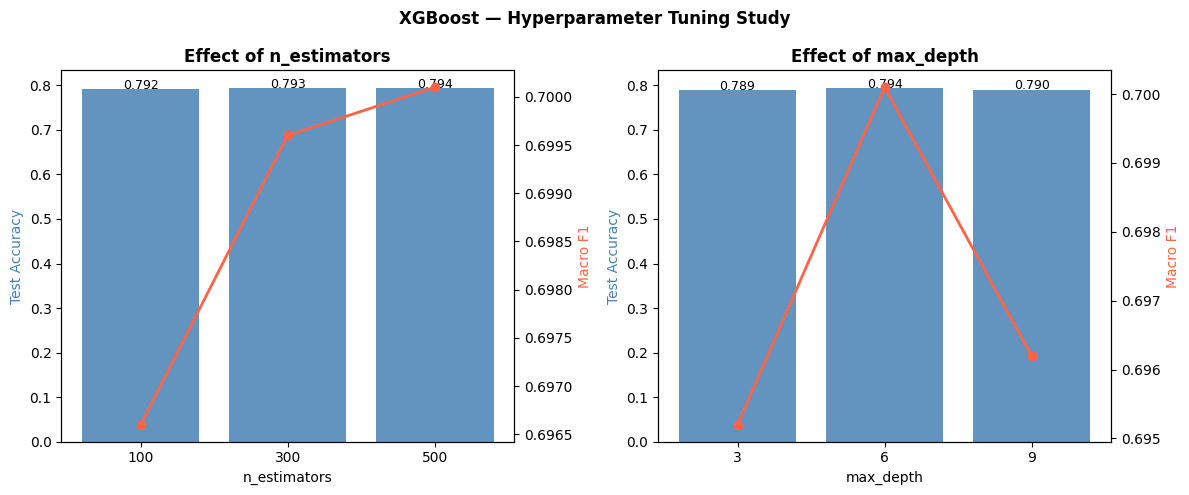

In [377]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (hp_name, df, x_col) in zip(axes, [
    ('n_estimators', hp_results['n_estimators'], 'n_estimators'),
    ('max_depth',    hp_results['max_depth'],    'max_depth'),
]):
    x_labels = df[x_col].astype(str).tolist()
    ax.bar(x_labels, df['Test Acc'], color='steelblue', alpha=0.85)
    ax2 = ax.twinx()
    ax2.plot(x_labels, df['Macro F1'], color='tomato', marker='o', linewidth=2)
    ax.set_title(f'Effect of {hp_name}', fontweight='bold')
    ax.set_xlabel(hp_name)
    ax.set_ylabel('Test Accuracy', color='steelblue')
    ax2.set_ylabel('Macro F1', color='tomato')
    for i, v in enumerate(df['Test Acc']):
        ax.text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('XGBoost — Hyperparameter Tuning Study', fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_hp_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

In [378]:
summary_all = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in all_results
]).sort_values('Macro F1', ascending=False).reset_index(drop=True)

best = summary_all.iloc[0]

print("=" * 50)
print("BEST MODEL ACROSS ALL EXPERIMENTS")
print("=" * 50)
print(f"Model        : {best['Model']}")
print(f"Macro F1     : {best['Macro F1']}")
print(f"Balanced Acc : {best['Balanced Acc']}")
print(f"Test Acc     : {best['Test Acc']}")
print(f"Kappa        : {best['Kappa']}")
print(f"Overfit Gap  : {round(best['Train Acc'] - best['Test Acc'], 4)}")
print("=" * 50)

BEST MODEL ACROSS ALL EXPERIMENTS
Model        : XGBoost [No-Synthetic]
Macro F1     : 0.7001
Balanced Acc : 0.711
Test Acc     : 0.7942
Kappa        : 0.5152
Overfit Gap  : -0.0589


#Saving

In [383]:
from sklearn.ensemble import RandomForestRegressor

# Retrain runtime imputer (was deleted to free RAM)
features_rt  = ['vote_count_log', 'quality_confidence', 'vote_average', 'is_released']
train_known  = X_train[X_train['runtime'].notna()]
model_runtime = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_runtime.fit(train_known[features_rt], train_known['runtime'])
print("model_runtime retrained ✓")

NameError: name 'X_train' is not defined

In [384]:
import pickle

def save(obj, path):
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f"  saved → {path}")

print("Saving preprocessing artefacts …")
save(imputer,           'cls_imputer.pkl')
#save(model_runtime,     'cls_model_runtime.pkl')
save(mlb_countries,     'cls_mlb_countries.pkl')
save(mlb_genres,        'cls_mlb_genres.pkl')
save(scaler,            'cls_scaler.pkl')
save(top_langs,         'cls_top_langs.pkl')
save(top_companies,     'cls_top_companies.pkl')
save(top5_countries,    'cls_top5_countries.pkl')
save(SELECTED_FEATURES, 'cls_selected_features.pkl')
save(train_age_median,  'cls_train_age_median.pkl')
save(roi_median,        'cls_roi_median.pkl')
save(label_map,         'cls_label_map.pkl')       # {'Very Low':0,'Low':1,'Medium':2,'High':3}

print("\nSaving trained classifiers …")
save(lr_model,   'cls_model_lr.pkl')
save(rf_model,   'cls_model_rf.pkl')
save(xgb_model,  'cls_model_xgb.pkl')
save(lgbm_model, 'cls_model_lgbm.pkl')
save(cat_model,  'cls_model_cat.pkl')
save(et_model,   'cls_model_et.pkl')

print("\nAll files saved successfully!")

Saving preprocessing artefacts …
  saved → cls_imputer.pkl
  saved → cls_mlb_countries.pkl
  saved → cls_mlb_genres.pkl
  saved → cls_scaler.pkl
  saved → cls_top_langs.pkl
  saved → cls_top_companies.pkl
  saved → cls_top5_countries.pkl
  saved → cls_selected_features.pkl
  saved → cls_train_age_median.pkl
  saved → cls_roi_median.pkl
  saved → cls_label_map.pkl

Saving trained classifiers …
  saved → cls_model_lr.pkl
  saved → cls_model_rf.pkl
  saved → cls_model_xgb.pkl
  saved → cls_model_lgbm.pkl
  saved → cls_model_cat.pkl
  saved → cls_model_et.pkl

All files saved successfully!


In [385]:
import os
cls_files = [f for f in os.listdir('.') if f.startswith('cls_')]
print(f"\nFound {len(cls_files)} cls_*.pkl files in working directory:")
for f in sorted(cls_files):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f:45s}  {size_kb:8.1f} KB")


Found 17 cls_*.pkl files in working directory:
  cls_imputer.pkl                                    37.3 KB
  cls_label_map.pkl                                   0.1 KB
  cls_mlb_countries.pkl                               0.4 KB
  cls_mlb_genres.pkl                                  0.4 KB
  cls_model_cat.pkl                                1305.6 KB
  cls_model_et.pkl                               110017.0 KB
  cls_model_lgbm.pkl                              13467.1 KB
  cls_model_lr.pkl                                    1.3 KB
  cls_model_rf.pkl                               288545.3 KB
  cls_model_xgb.pkl                                7542.4 KB
  cls_roi_median.pkl                                  0.0 KB
  cls_scaler.pkl                                      1.3 KB
  cls_selected_features.pkl                           0.3 KB
  cls_top5_countries.pkl                              0.1 KB
  cls_top_companies.pkl                               0.4 KB
  cls_top_langs.pkl                  

In [386]:
from google.colab import files
import os

for f in os.listdir('.'):
    if f.startswith('cls_') and f.endswith('.pkl'):
        files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>